# 基于LSTM的期货趋势预测——螺纹钢主力合约涨跌预测实战

---

**课程名称**：深度学习与神经网络  
**实验选题**：循环神经网络实战 + 优化算法对比 + 模型调优  
**实验任务**：基于LSTM预测螺纹钢主力合约下一交易日涨跌方向  
**数据来源**：AKShare（新浪财经）螺纹钢连续合约（RB0）日线行情  
**实验日期**：2026-06-16  

---

## 选题说明

本实验选取**循环神经网络实战**为核心方向，结合**优化算法对比**与**深度学习模型调优**，
构建完整的期货趋势预测实验案例。同时引入**基础神经网络(MLP)**作为基线模型，
并与**传统机器学习方法(Random Forest, XGBoost)**进行横向对比。

---


## 二、环境配置与数据准备

### 2.1 导入依赖库

In [7]:
# ============================================================
# 环境配置：导入所有依赖库
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# PyTorch 深度学习框架
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# 机器学习 & 评估指标
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)
import xgboost as xgb

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

# PyTorch 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch 版本: {torch.__version__}")
print(f"计算设备: {device}")
print(f"所有依赖库导入成功！")


PyTorch 版本: 2.9.1+cpu
计算设备: cpu
所有依赖库导入成功！


### 2.2 数据获取

使用 **AKShare** 库从新浪财经获取螺纹钢连续合约（RB0）历史日线行情数据。

数据包含完整的 OHLCVA（开盘价、最高价、最低价、收盘价、成交量、成交额）日线信息，
时间范围覆盖 2020 年至今。



In [9]:
# ============================================================
# 数据获取 - AKShare
# ============================================================
import akshare as ak

print("正在从 AKShare（新浪财经）获取螺纹钢期货数据...")
df = ak.futures_zh_daily_sina(symbol='RB0')
print(f"AKShare 原始列名: {list(df.columns)}")

# 统一列名（兼容中英文列名）
col_map = {
    '日期': 'trade_date', 'date': 'trade_date',
    '开盘价': 'open', 'open': 'open',
    '最高价': 'high', 'high': 'high',
    '最低价': 'low', 'low': 'low',
    '收盘价': 'close', 'close': 'close',
    '成交量': 'volume', 'volume': 'volume',
}
df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})

# 计算成交额（螺纹钢合约乘数 = 10 吨/手）
if 'amount' not in df.columns:
    df['amount'] = df['volume'] * df['close'] * 10

# 统一日期格式为 YYYYMMDD，只保留 2020 年之后的数据
df['trade_date'] = pd.to_datetime(df['trade_date']).dt.strftime('%Y%m%d')
df = df[df['trade_date'] >= '20200101'].sort_values('trade_date').reset_index(drop=True)

DATA_SOURCE = 'AKShare (新浪财经)'

print("=" * 50)
print(f"数据加载完成！数据源: {DATA_SOURCE}")
print("=" * 50)
print(f"数据形状: {df.shape}")
print(f"时间范围: {df['trade_date'].iloc[0]} ~ {df['trade_date'].iloc[-1]}")
print(f"价格范围: {df['close'].min():.1f} ~ {df['close'].max():.1f}")
print(f"\n数据前5行预览:")
display(df.head())
print(f"\n数据信息:")
df.info()

正在从 AKShare（新浪财经）获取螺纹钢期货数据...
AKShare 原始列名: ['date', 'open', 'high', 'low', 'close', 'volume', 'hold', 'settle']
数据加载完成！数据源: AKShare (新浪财经)
数据形状: (1562, 9)
时间范围: 20200102 ~ 20260616
价格范围: 2928.0 ~ 6171.0

数据前5行预览:


,trade_date,open,high,low,close,volume,hold,settle,amount
0,20200102,3584.0,3593.0,3540.0,3547.0,976947,1443715,3563.0,3.465231e+10
1,20200103,3547.0,3567.0,3542.0,3543.0,778292,1398669,3552.0,2.757489e+10
2,20200106,3540.0,3566.0,3526.0,3559.0,966449,1381265,3549.0,3.439592e+10
3,20200107,3558.0,3580.0,3556.0,3574.0,708368,1400763,3569.0,2.531707e+10
4,20200108,3574.0,3621.0,3571.0,3617.0,1051293,1419374,3602.0,3.802527e+10



数据信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1562 entries, 0 to 1561
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   trade_date  1562 non-null   object 
 1   open        1562 non-null   float64
 2   high        1562 non-null   float64
 3   low         1562 non-null   float64
 4   close       1562 non-null   float64
 5   volume      1562 non-null   int64  
 6   hold        1562 non-null   int64  
 7   settle      1562 non-null   float64
 8   amount      1562 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 110.0+ KB


### 2.3 数据预处理

In [10]:
# ============================================================
# 数据预处理：构建日期索引
# ============================================================
df['date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df = df.sort_values('date').reset_index(drop=True)
df = df.set_index('date')

print(f"交易日数量: {len(df)}")
print(f"日期范围: {df.index[0].strftime('%Y-%m-%d')} ~ {df.index[-1].strftime('%Y-%m-%d')}")


交易日数量: 1562
日期范围: 2020-01-02 ~ 2026-06-16


## 三、探索性数据分析（EDA）

### 3.1 价格走势可视化

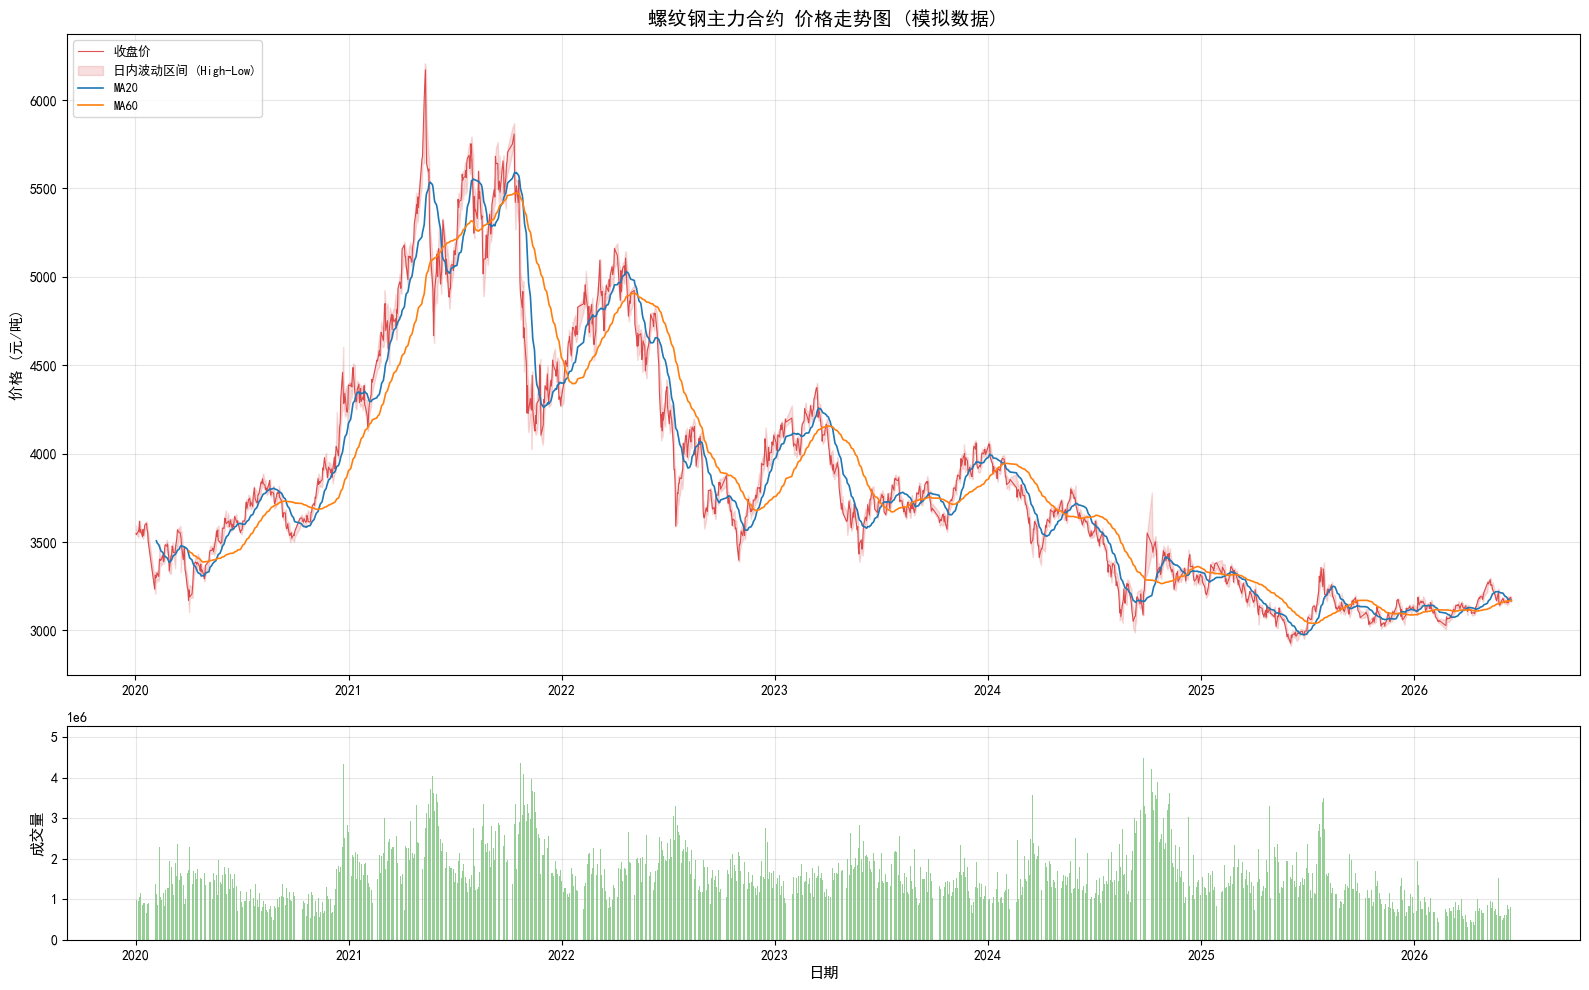

图1: 螺纹钢期货价格走势及成交量分布


In [11]:
# ============================================================
# EDA-1: 价格走势图
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 10), 
                          gridspec_kw={'height_ratios': [3, 1]})

# 上半部分：收盘价 + 日内波动区间 + 移动平均线
ax1 = axes[0]
ax1.plot(df.index, df['close'], color='#d62728', linewidth=0.8, alpha=0.8, label='收盘价')
ax1.fill_between(df.index, df['low'], df['high'], alpha=0.15, 
                  color='#d62728', label='日内波动区间 (High-Low)')

# 移动平均线
ma20 = df['close'].rolling(20).mean()
ma60 = df['close'].rolling(60).mean()
ax1.plot(df.index, ma20, color='#1f77b4', linewidth=1.2, label='MA20')
ax1.plot(df.index, ma60, color='#ff7f0e', linewidth=1.2, label='MA60')

ax1.set_title('螺纹钢主力合约 价格走势图 (模拟数据)', fontsize=14, fontweight='bold')
ax1.set_ylabel('价格 (元/吨)', fontsize=11)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# 下半部分：成交量
ax2 = axes[1]
ax2.bar(df.index, df['volume'], color='#2ca02c', alpha=0.5, width=1)
ax2.set_ylabel('成交量', fontsize=11)
ax2.set_xlabel('日期', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('price_trend.png', bbox_inches='tight', dpi=150)
plt.show()
print("图1: 螺纹钢期货价格走势及成交量分布")


### 3.2 收益率分布分析

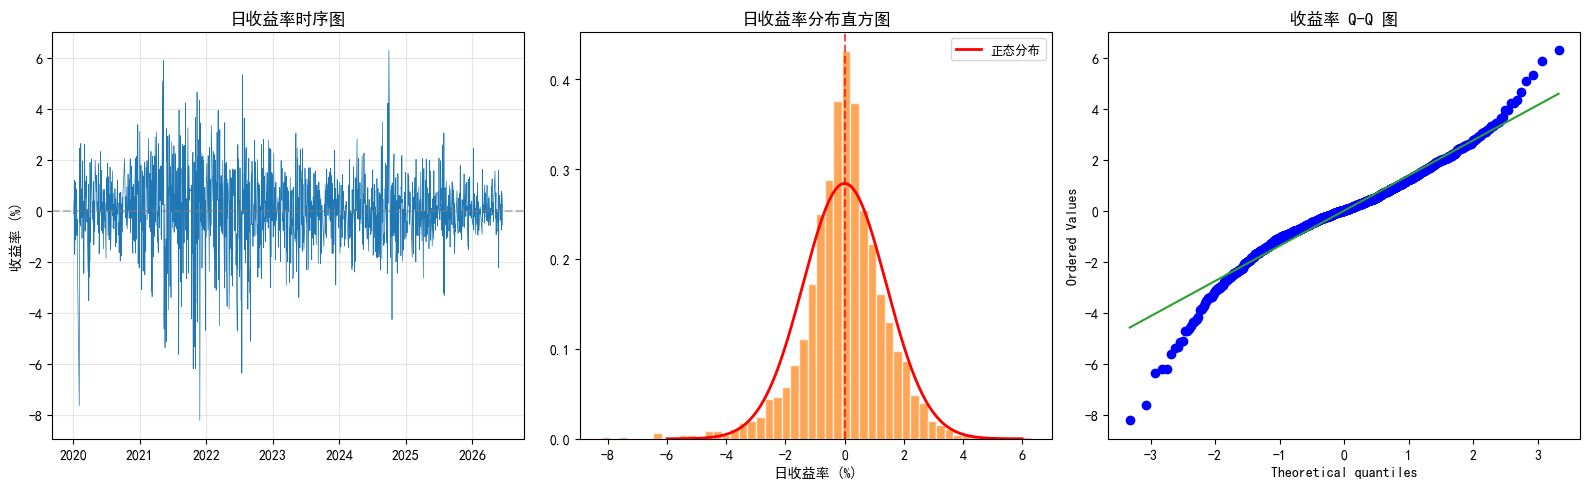

收益率统计:
  均值:  0.003%
  标准差: 1.406%
  偏度:  -0.509
  峰度:  3.296
  正收益占比: 50.4%


In [12]:
# ============================================================
# EDA-2: 日收益率分布分析
# ============================================================
df['returns'] = df['close'].pct_change()
df['log_returns'] = np.log(df['close'] / df['close'].shift(1))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 收益率的时序图
axes[0].plot(df.index, df['returns'] * 100, color='#1f77b4', linewidth=0.5)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('日收益率时序图', fontsize=12, fontweight='bold')
axes[0].set_ylabel('收益率 (%)', fontsize=10)
axes[0].grid(True, alpha=0.3)

# 收益率的分布直方图
returns_clean = df['returns'].dropna() * 100
axes[1].hist(returns_clean, bins=50, color='#ff7f0e', 
             alpha=0.7, edgecolor='white', density=True)
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
# 叠加正态分布
from scipy import stats
x = np.linspace(-6, 6, 200)
mu_r = returns_clean.mean()
sigma_r = returns_clean.std()
axes[1].plot(x, stats.norm.pdf(x, mu_r, sigma_r), 'r-', linewidth=2, label='正态分布')
axes[1].set_title('日收益率分布直方图', fontsize=12, fontweight='bold')
axes[1].set_xlabel('日收益率 (%)', fontsize=10)
axes[1].legend(fontsize=9)

# Q-Q 图
stats.probplot(returns_clean, dist="norm", plot=axes[2])
axes[2].set_title('收益率 Q-Q 图', fontsize=12, fontweight='bold')
axes[2].get_lines()[1].set_color('#2ca02c')

plt.tight_layout()
plt.savefig('returns_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("收益率统计:")
print(f"  均值:  {returns_clean.mean():.3f}%")
print(f"  标准差: {returns_clean.std():.3f}%")
print(f"  偏度:  {df['returns'].skew():.3f}")
print(f"  峰度:  {df['returns'].kurtosis():.3f}")
print(f"  正收益占比: {(df['returns'] > 0).sum() / len(df.dropna()) * 100:.1f}%")


### 3.3 统计特征与相关性分析

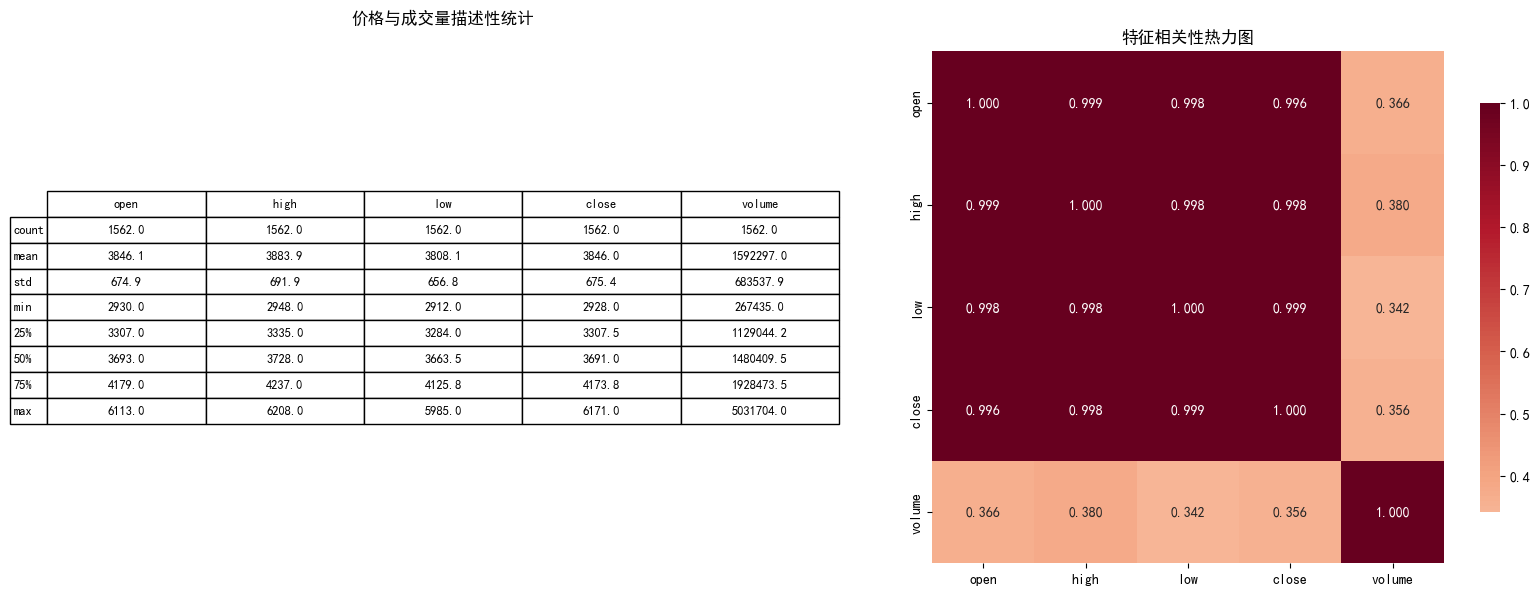


EDA小结：
1. 价格序列呈现明显的趋势性和波动聚集特征
2. 收益率分布呈现尖峰厚尾（峰度 > 3），是金融数据典型特征
3. OHLC价格高度相关，成交量与价格相关性较低
4. 数据具有时序依赖特征，适合LSTM建模


In [13]:
# ============================================================
# EDA-3: 统计特征 + 相关性
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 描述性统计表
stats_df = df[['open', 'high', 'low', 'close', 'volume']].describe().round(1)
axes[0].axis('tight')
axes[0].axis('off')
table = axes[0].table(cellText=stats_df.values,
                      colLabels=stats_df.columns,
                      rowLabels=stats_df.index,
                      cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.4)
axes[0].set_title('价格与成交量描述性统计', fontsize=12, fontweight='bold', pad=20)

# 相关性热力图
corr_cols = ['open', 'high', 'low', 'close', 'volume']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('特征相关性热力图', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_statistics.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nEDA小结：")
print("1. 价格序列呈现明显的趋势性和波动聚集特征")
print("2. 收益率分布呈现尖峰厚尾（峰度 > 3），是金融数据典型特征")
print("3. OHLC价格高度相关，成交量与价格相关性较低")
print("4. 数据具有时序依赖特征，适合LSTM建模")


## 四、特征工程

特征工程是量化交易模型的核心环节。我们从OHLCV原始数据构建丰富的技术指标特征，
将时序预测问题转化为监督学习问题。

### 4.1 技术指标计算

In [14]:
# ============================================================
# 特征工程：技术指标批量计算
# ============================================================
def compute_technical_features(df):
    # 基于OHLCV计算30+技术指标特征
    # 包括：价格特征、趋势指标、动量指标、波动率指标、成交量指标
    data = df.copy()
    
    # --- 1. 价格基础特征 ---
    data['returns_1d'] = data['close'].pct_change()
    data['returns_5d'] = data['close'].pct_change(5)
    data['returns_10d'] = data['close'].pct_change(10)
    data['price_position'] = (data['close'] - data['low'].rolling(20).min()) / \
                             (data['high'].rolling(20).max() - data['low'].rolling(20).min() + 1e-10)
    
    # --- 2. 移动平均线特征 ---
    for window in [5, 10, 20, 60]:
        data[f'MA_{window}'] = data['close'].rolling(window).mean()
        data[f'MA_{window}_ratio'] = data['close'] / data[f'MA_{window}'] - 1  # 偏离度
    
    # --- 3. MACD ---
    ema_12 = data['close'].ewm(span=12, adjust=False).mean()
    ema_26 = data['close'].ewm(span=26, adjust=False).mean()
    data['MACD'] = ema_12 - ema_26
    data['MACD_signal'] = data['MACD'].ewm(span=9, adjust=False).mean()
    data['MACD_hist'] = data['MACD'] - data['MACD_signal']
    
    # --- 4. RSI ---
    delta = data['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    data['RSI'] = 100 - (100 / (1 + gain / (loss + 1e-10)))
    
    # --- 5. 布林带 ---
    data['BB_mid'] = data['close'].rolling(20).mean()
    bb_std = data['close'].rolling(20).std()
    data['BB_upper'] = data['BB_mid'] + 2 * bb_std
    data['BB_lower'] = data['BB_mid'] - 2 * bb_std
    data['BB_width'] = (data['BB_upper'] - data['BB_lower']) / data['BB_mid']
    data['BB_position'] = (data['close'] - data['BB_lower']) / \
                          (data['BB_upper'] - data['BB_lower'] + 1e-10)
    
    # --- 6. 波动率 ---
    data['volatility_5d'] = data['returns_1d'].rolling(5).std()
    data['volatility_20d'] = data['returns_1d'].rolling(20).std()
    # ATR
    high_low = data['high'] - data['low']
    high_close = abs(data['high'] - data['close'].shift(1))
    low_close = abs(data['low'] - data['close'].shift(1))
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    data['ATR'] = tr.rolling(14).mean()
    data['ATR_ratio'] = data['ATR'] / data['close']
    
    # --- 7. 成交量特征 ---
    data['volume_ma5'] = data['volume'].rolling(5).mean()
    data['volume_ma20'] = data['volume'].rolling(20).mean()
    data['volume_ratio'] = data['volume'] / (data['volume_ma20'] + 1)
    data['volume_change'] = data['volume'].pct_change()
    
    # --- 8. OBV ---
    data['OBV'] = (np.sign(data['close'].diff()) * data['volume']).fillna(0).cumsum()
    data['OBV_change'] = data['OBV'].pct_change(5)
    
    # --- 9. ROC ---
    data['ROC_5'] = data['close'].pct_change(5) * 100
    data['ROC_10'] = data['close'].pct_change(10) * 100
    
    # --- 10. 振幅 ---
    data['amplitude'] = (data['high'] - data['low']) / data['close'].shift(1)
    data['amplitude_ma5'] = data['amplitude'].rolling(5).mean()
    
    return data


# 计算技术指标
df_features = compute_technical_features(df)

original_cols = len(df.columns)
new_cols = len(df_features.columns)
print(f"原始特征数: {original_cols} (OHLCV)")
print(f"扩展后特征数: {new_cols}")
print(f"\\n新增技术指标特征 ({new_cols - original_cols}个):")
feature_cols = df_features.columns.tolist()
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")


原始特征数: 11 (OHLCV)
扩展后特征数: 46
\n新增技术指标特征 (35个):
   1. trade_date
   2. open
   3. high
   4. low
   5. close
   6. volume
   7. hold
   8. settle
   9. amount
  10. returns
  11. log_returns
  12. returns_1d
  13. returns_5d
  14. returns_10d
  15. price_position
  16. MA_5
  17. MA_5_ratio
  18. MA_10
  19. MA_10_ratio
  20. MA_20
  21. MA_20_ratio
  22. MA_60
  23. MA_60_ratio
  24. MACD
  25. MACD_signal
  26. MACD_hist
  27. RSI
  28. BB_mid
  29. BB_upper
  30. BB_lower
  31. BB_width
  32. BB_position
  33. volatility_5d
  34. volatility_20d
  35. ATR
  36. ATR_ratio
  37. volume_ma5
  38. volume_ma20
  39. volume_ratio
  40. volume_change
  41. OBV
  42. OBV_change
  43. ROC_5
  44. ROC_10
  45. amplitude
  46. amplitude_ma5


### 4.2 涨跌标签构建

删除缺失值后数据量: 1503
\n标签分布:
  上涨(1): 757 条 (50.4%)
  下跌(0): 746 条 (49.6%)


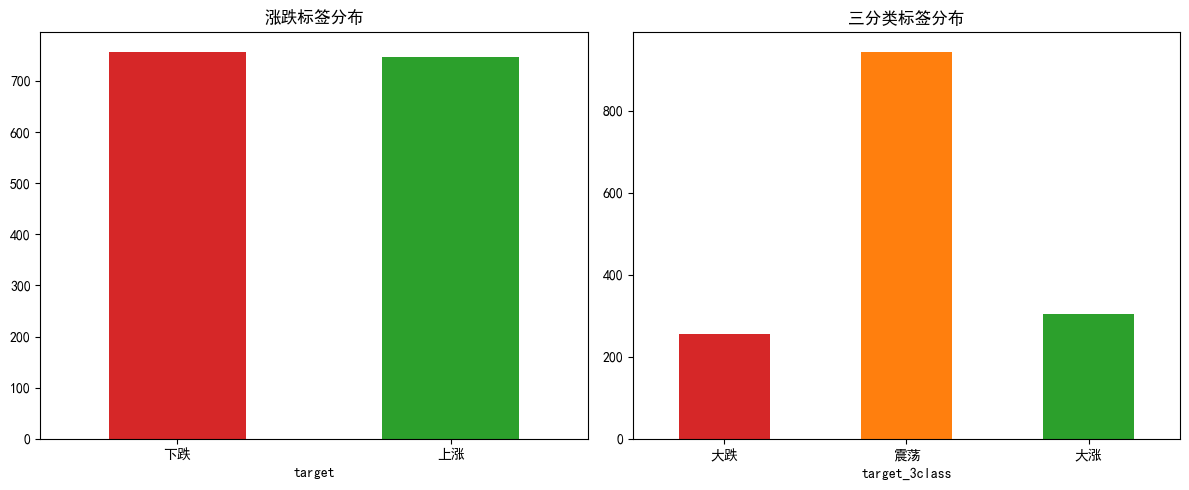

In [15]:
# ============================================================
# 标签构建：下一交易日涨跌
# ============================================================
df_features['target'] = (df_features['close'].shift(-1) > df_features['close']).astype(int)

# 三分类标签（用于辅助分析）
df_features['target_3class'] = 1
df_features.loc[df_features['close'].shift(-1) / df_features['close'] - 1 > 0.01, 'target_3class'] = 2
df_features.loc[df_features['close'].shift(-1) / df_features['close'] - 1 < -0.01, 'target_3class'] = 0

df_features = df_features.dropna()

print(f"删除缺失值后数据量: {len(df_features)}")
print(f"\\n标签分布:")
print(f"  上涨(1): {(df_features['target']==1).sum()} 条 "
      f"({(df_features['target']==1).sum()/len(df_features)*100:.1f}%)")
print(f"  下跌(0): {(df_features['target']==0).sum()} 条 "
      f"({(df_features['target']==0).sum()/len(df_features)*100:.1f}%)")

# 标签分布可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df_features['target'].value_counts().plot(kind='bar', ax=axes[0], 
    color=['#d62728', '#2ca02c'])
axes[0].set_title('涨跌标签分布', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['下跌', '上涨'], rotation=0)

df_features['target_3class'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#d62728', '#ff7f0e', '#2ca02c'])
axes[1].set_title('三分类标签分布', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['大跌', '震荡', '大涨'], rotation=0)

plt.tight_layout()
plt.savefig('label_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


### 4.3 特征选择与标准化

In [16]:
# ============================================================
# 特征选择与数据标准化
# ============================================================
# 排除非特征列
exclude_cols = ['trade_date', 'open', 'high', 'low', 'close', 'volume', 'amount',
                'target', 'target_3class']
feature_cols = [col for col in df_features.columns if col not in exclude_cols]

print(f"模型输入特征数: {len(feature_cols)}")
print(f"特征列表: {feature_cols}")

X = df_features[feature_cols].values
y = df_features['target'].values

print(f"\\n特征矩阵形状: {X.shape}, 标签形状: {y.shape}")

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\\n标准化后均值: {X_scaled.mean():.4f}, 标准差: {X_scaled.std():.4f}")


模型输入特征数: 39
特征列表: ['hold', 'settle', 'returns', 'log_returns', 'returns_1d', 'returns_5d', 'returns_10d', 'price_position', 'MA_5', 'MA_5_ratio', 'MA_10', 'MA_10_ratio', 'MA_20', 'MA_20_ratio', 'MA_60', 'MA_60_ratio', 'MACD', 'MACD_signal', 'MACD_hist', 'RSI', 'BB_mid', 'BB_upper', 'BB_lower', 'BB_width', 'BB_position', 'volatility_5d', 'volatility_20d', 'ATR', 'ATR_ratio', 'volume_ma5', 'volume_ma20', 'volume_ratio', 'volume_change', 'OBV', 'OBV_change', 'ROC_5', 'ROC_10', 'amplitude', 'amplitude_ma5']
\n特征矩阵形状: (1503, 39), 标签形状: (1503,)
\n标准化后均值: 0.0000, 标准差: 1.0000


### 4.4 滑动窗口序列构建

将时序数据转换为LSTM所需的 (样本数, 时间步长, 特征数) 三维格式。

In [17]:
# ============================================================
# 滑动窗口序列构建
# ============================================================
WINDOW_SIZE = 20  # 使用过去20个交易日数据

def create_sequences(X, y, window_size=WINDOW_SIZE):
    # 将时序数据转换为监督学习序列
    # 返回: X_seq (n, window_size, n_features), y_seq (n,)
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y)

print(f"窗口大小: {WINDOW_SIZE} 个交易日")
print(f"序列数据形状: {X_seq.shape}")
print(f"每个样本: {X_seq.shape[1]} 个时间步 x {X_seq.shape[2]} 个特征")
print(f"标签形状: {y_seq.shape}")


窗口大小: 20 个交易日
序列数据形状: (1483, 20, 39)
每个样本: 20 个时间步 x 39 个特征
标签形状: (1483,)


### 4.5 数据集划分（严格时序分割）

金融时序数据**绝对不能随机打乱**，必须按时间顺序划分，避免未来信息泄露。

In [18]:
# ============================================================
# 数据集划分（严格时间顺序）
# ============================================================
total = len(X_seq)
train_size = int(total * 0.70)
val_size = int(total * 0.15)

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]
X_val = X_seq[train_size:train_size + val_size]
y_val = y_seq[train_size:train_size + val_size]
X_test = X_seq[train_size + val_size:]
y_test = y_seq[train_size + val_size:]

print("=" * 50)
print("数据集划分（严格时序分割，无随机打乱）")
print("=" * 50)
print(f"总样本:   {total}")
print(f"训练集:   {len(X_train)} 条 ({len(X_train)/total*100:.1f}%)")
print(f"验证集:   {len(X_val)} 条 ({len(X_val)/total*100:.1f}%)")
print(f"测试集:   {len(X_test)} 条 ({len(X_test)/total*100:.1f}%)")
print(f"\\n训练集涨跌比: 1:{y_train.sum()}/{len(y_train)-y_train.sum()}")
print(f"测试集涨跌比: 1:{y_test.sum()}/{len(y_test)-y_test.sum()}")

# 转换为 PyTorch Tensor
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

print(f"\\nPyTorch Tensor 就绪: "
      f"X_train={list(X_train_t.shape)}, X_test={list(X_test_t.shape)}")


数据集划分（严格时序分割，无随机打乱）
总样本:   1483
训练集:   1038 条 (70.0%)
验证集:   222 条 (15.0%)
测试集:   223 条 (15.0%)
\n训练集涨跌比: 1:535/503
测试集涨跌比: 1:109/114
\nPyTorch Tensor 就绪: X_train=[1038, 20, 39], X_test=[223, 20, 39]


## 五、基础神经网络实战——MLP基线模型

使用全连接神经网络（MLP）建立基线模型。MLP将时间窗口内所有特征展平，
作为后续LSTM模型的性能参照基准。

### 5.1 MLP模型定义

In [19]:
# ============================================================
# MLP 全连接神经网络
# ============================================================
class MLPClassifier(nn.Module):
    # 多层感知机分类器
    # 结构：Input -> FC(256)+BN+ReLU+Dropout -> FC(128)+BN+ReLU+Dropout
    #              -> FC(64)+BN+ReLU+Dropout -> FC(1)+Sigmoid
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], dropout=0.3):
        super(MLPClassifier, self).__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1)  # 展平时间维度
        return self.network(x)


input_dim = WINDOW_SIZE * X_train.shape[2]
mlp_model = MLPClassifier(input_dim=input_dim).to(device)

n_params = sum(p.numel() for p in mlp_model.parameters())
print(f"MLP模型: 输入维度={input_dim}, 参数量={n_params:,}")
print(mlp_model)


MLP模型: 输入维度=780, 参数量=242,049
MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=780, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
    (13): Sigmoid()
  )
)


### 5.2 通用训练/评估函数

In [20]:
# ============================================================
# 训练与评估函数
# ============================================================
def train_epoch(model, loader, criterion, optimizer, device):
    # 训练一个epoch
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        preds = (outputs > 0.5).float()
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    # 评估模型，返回损失、准确率、预测值和真实标签
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            preds = (outputs > 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, criterion, optimizer, 
                scheduler=None, epochs=100, patience=15, model_name='model'):
    # 完整训练流程（含早停、学习率调度）
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_epoch = 0
    patience_counter = 0
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        
        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        if patience_counter >= patience:
            print(f"早停触发于 Epoch {epoch+1} (最佳为 Epoch {best_epoch+1})")
            break
    
    model.load_state_dict(best_model_state)
    return history, best_model_state, best_epoch


print("训练/评估函数定义完成！")


训练/评估函数定义完成！


### 5.3 MLP训练

In [21]:
# ============================================================
# MLP训练
# ============================================================
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.BCELoss()
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-5)
mlp_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    mlp_optimizer, mode='min', factor=0.5, patience=10)

print("训练 MLP 基线模型...")
print("-" * 50)
mlp_history, mlp_best_state, mlp_best_epoch = train_model(
    mlp_model, train_loader, val_loader, criterion, mlp_optimizer,
    scheduler=mlp_scheduler, epochs=100, patience=15, model_name='MLP'
)
print(f"\\nMLP 训练完成！最佳验证损失: {min(mlp_history['val_loss']):.4f} "
      f"(Epoch {mlp_best_epoch+1})")


训练 MLP 基线模型...
--------------------------------------------------
早停触发于 Epoch 16 (最佳为 Epoch 1)
\nMLP 训练完成！最佳验证损失: 0.7458 (Epoch 1)


### 5.4 MLP代价函数分析

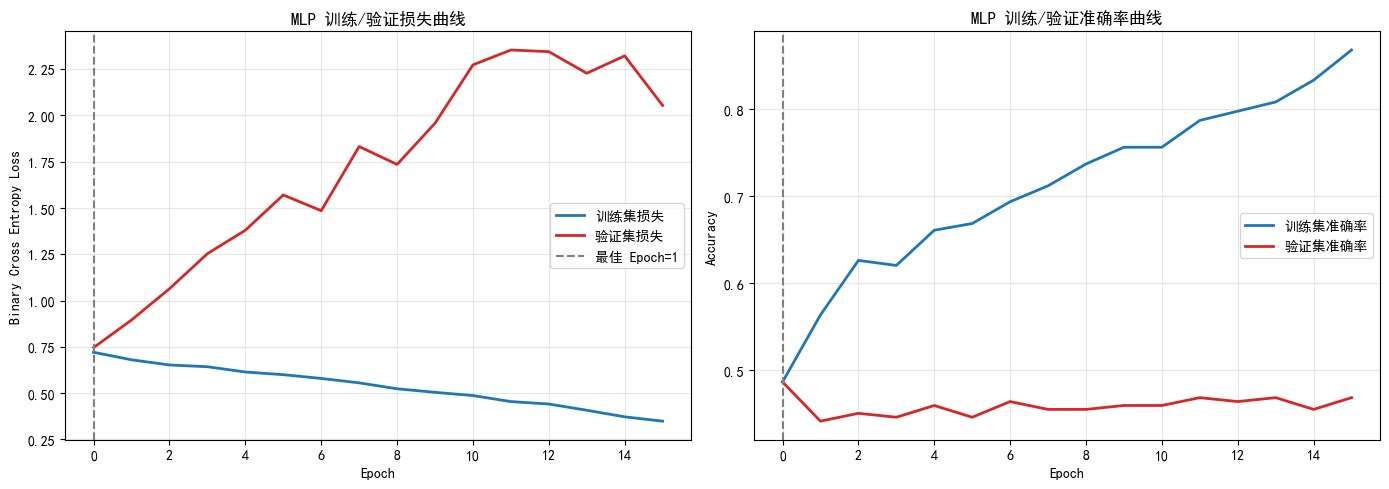

MLP 基线模型 - 测试集评估
测试损失:     0.7485
准确率:       0.4933
精确率:       0.4910
召回率:       1.0000
F1分数:       0.6586
AUC:          0.5044
\n混淆矩阵:
[[  1 113]
 [  0 109]]


In [22]:
# ============================================================
# MLP - 训练/验证代价函数分析
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(mlp_history['train_loss'], label='训练集损失', color='#1f77b4', linewidth=2)
axes[0].plot(mlp_history['val_loss'], label='验证集损失', color='#d62728', linewidth=2)
axes[0].axvline(x=mlp_best_epoch, color='gray', linestyle='--', 
                label=f'最佳 Epoch={mlp_best_epoch+1}')
axes[0].set_title('MLP 训练/验证损失曲线', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(mlp_history['train_acc'], label='训练集准确率', color='#1f77b4', linewidth=2)
axes[1].plot(mlp_history['val_acc'], label='验证集准确率', color='#d62728', linewidth=2)
axes[1].axvline(x=mlp_best_epoch, color='gray', linestyle='--')
axes[1].set_title('MLP 训练/验证准确率曲线', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_training.png', bbox_inches='tight', dpi=150)
plt.show()

# 测试集评估
mlp_test_loss, mlp_test_acc, mlp_preds, mlp_labels = evaluate(
    mlp_model, test_loader, criterion, device)

print("=" * 50)
print("MLP 基线模型 - 测试集评估")
print("=" * 50)
print(f"测试损失:     {mlp_test_loss:.4f}")
print(f"准确率:       {mlp_test_acc:.4f}")
print(f"精确率:       {precision_score(mlp_labels, mlp_preds):.4f}")
print(f"召回率:       {recall_score(mlp_labels, mlp_preds):.4f}")
print(f"F1分数:       {f1_score(mlp_labels, mlp_preds):.4f}")
print(f"AUC:          {roc_auc_score(mlp_labels, mlp_preds):.4f}")
print(f"\\n混淆矩阵:")
print(confusion_matrix(mlp_labels, mlp_preds))


## 六、循环神经网络实战——LSTM核心模型

### 6.1 LSTM模型设计

核心模型采用2层堆叠双向LSTM + 注意力池化机制：

| 组件 | 配置 |
|-----|------|
| LSTM层1 | 双向, hidden=128 |
| LSTM层2 | 双向, hidden=64 |
| 注意力层 | 自注意力加权池化 |
| 分类头 | FC(64)→BN→ReLU→Dropout→FC(32)→BN→ReLU→Dropout→Sigmoid |
| 正则化 | Dropout=0.3, WeightDecay=1e-4 |


In [23]:
# ============================================================
# LSTM 模型定义
# ============================================================
class LSTMPredictor(nn.Module):
    # 基于LSTM + 注意力机制的期货涨跌预测模型
    # 2层双向LSTM → 自注意力池化 → 全连接分类
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.3):
        super(LSTMPredictor, self).__init__()
        self.hidden_dim = hidden_dim
        
        # 第一层双向LSTM
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, num_layers=1,
                             batch_first=True, bidirectional=True, dropout=0)
        # 第二层双向LSTM（输入为hidden_dim*2，因为上一层是双向的）
        self.lstm2 = nn.LSTM(hidden_dim * 2, hidden_dim // 2, num_layers=1,
                             batch_first=True, bidirectional=True, dropout=0)
        
        lstm_out_dim = hidden_dim  # (hidden_dim//2 * 2)
        
        # 注意力机制：学习每个时间步的重要性权重
        self.attention = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.Tanh(),
            nn.Linear(lstm_out_dim // 2, 1)
        )
        
        # 分类头
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        self.dropout_layer = nn.Dropout(dropout)
    
    def forward(self, x):
        # x: (batch, seq_len, features)
        out1, _ = self.lstm1(x)
        out1 = self.dropout_layer(out1)
        out2, _ = self.lstm2(out1)
        
        # 注意力加权池化
        attn_weights = self.attention(out2)  # (batch, seq_len, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(out2 * attn_weights, dim=1)  # (batch, lstm_out_dim)
        
        return self.classifier(context)


# 实例化
n_features = X_train.shape[2]
lstm_model = LSTMPredictor(input_dim=n_features, hidden_dim=128, num_layers=2, dropout=0.3)
lstm_model = lstm_model.to(device)

n_params = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM模型: 输入维度=({WINDOW_SIZE}, {n_features}), 参数量={n_params:,}")
print(lstm_model)


LSTM模型: 输入维度=(20, 39), 参数量=356,802
LSTMPredictor(
  (lstm1): LSTM(39, 128, batch_first=True, bidirectional=True)
  (lstm2): LSTM(256, 64, batch_first=True, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
  (dropout_layer): Dropout(p=0.3, inplace=False)
)


### 6.2 LSTM模型训练

In [24]:
# ============================================================
# LSTM 训练
# ============================================================
lstm_optimizer = optim.AdamW(lstm_model.parameters(), lr=0.001, weight_decay=1e-4)
lstm_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    lstm_optimizer, T_0=20, T_mult=2, eta_min=1e-6)

print("训练 LSTM 模型...")
print("-" * 50)
lstm_history, lstm_best_state, lstm_best_epoch = train_model(
    lstm_model, train_loader, val_loader, criterion, lstm_optimizer,
    scheduler=lstm_scheduler, epochs=80, patience=15, model_name='LSTM'
)
print(f"\\nLSTM 训练完成！最佳验证损失: {min(lstm_history['val_loss']):.4f} "
      f"(Epoch {lstm_best_epoch+1})")


训练 LSTM 模型...
--------------------------------------------------
早停触发于 Epoch 16 (最佳为 Epoch 1)
\nLSTM 训练完成！最佳验证损失: 0.6958 (Epoch 1)


### 6.3 训练集与测试集代价函数分析

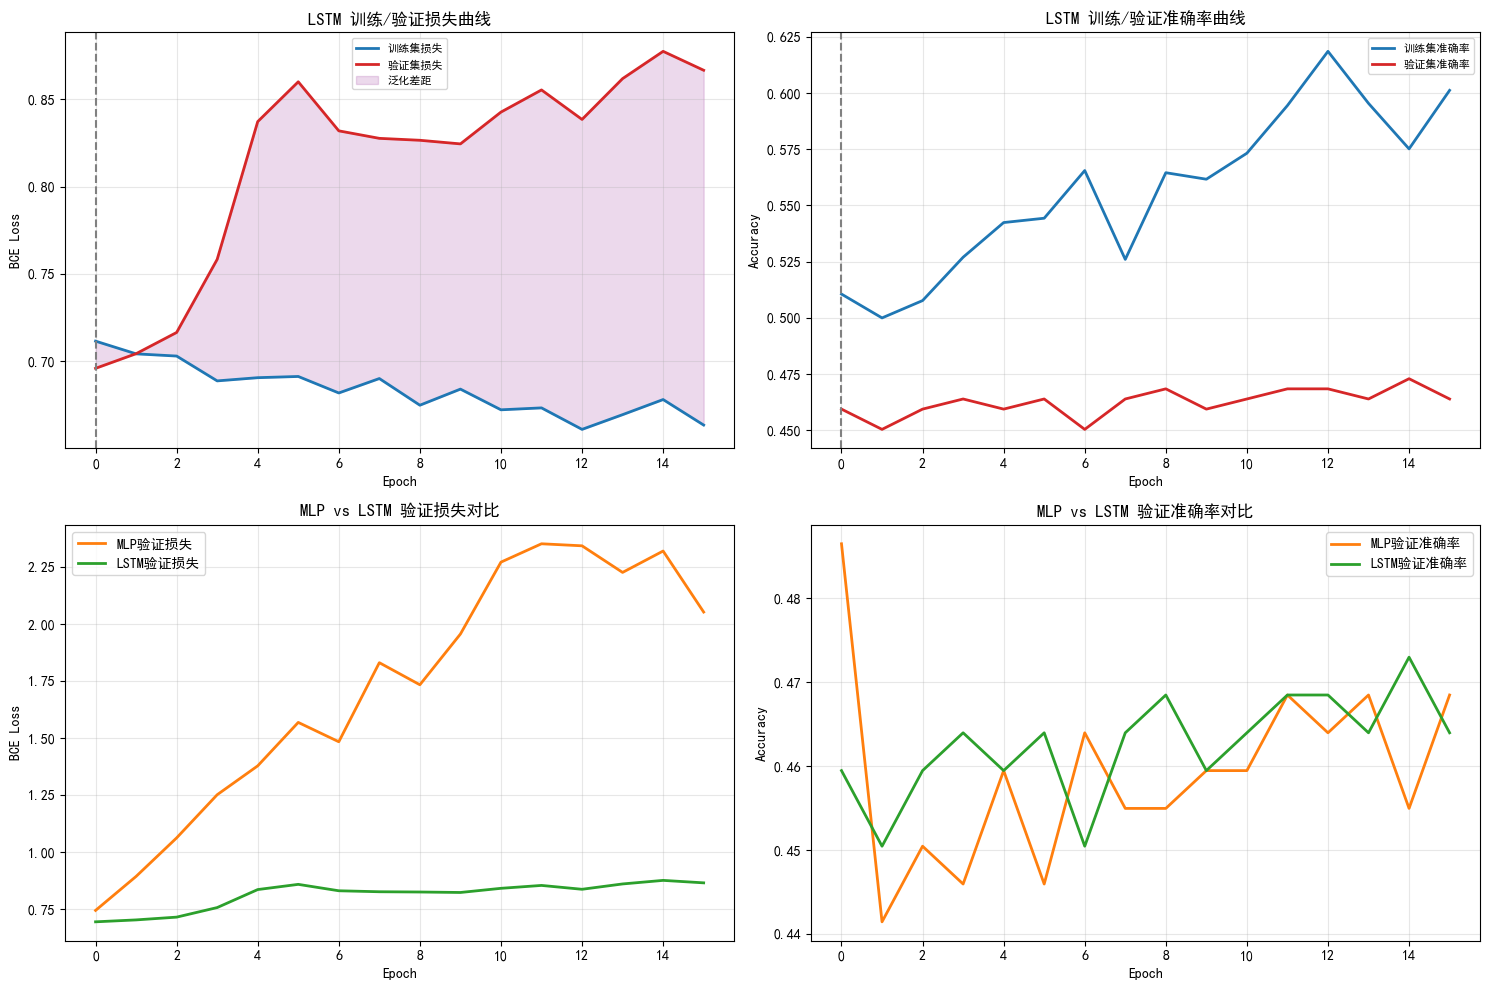

\n==================================================
代价函数分析总结
最终训练损失:  0.6633
最终验证损失:  0.8667
最佳验证损失:  0.6958
泛化差距:      -0.2034
\nLSTM vs MLP 验证损失降低: 0.0500


In [25]:
# ============================================================
# 代价函数分析：LSTM vs MLP
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. LSTM损失曲线
axes[0, 0].plot(lstm_history['train_loss'], label='训练集损失', color='#1f77b4', linewidth=2)
axes[0, 0].plot(lstm_history['val_loss'], label='验证集损失', color='#d62728', linewidth=2)
axes[0, 0].axvline(x=lstm_best_epoch, color='gray', linestyle='--')
axes[0, 0].fill_between(range(len(lstm_history['train_loss'])),
                         lstm_history['train_loss'], lstm_history['val_loss'],
                         alpha=0.15, color='purple', label='泛化差距')
axes[0, 0].set_title('LSTM 训练/验证损失曲线', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('BCE Loss')
axes[0, 0].legend(fontsize=8); axes[0, 0].grid(True, alpha=0.3)

# 2. LSTM准确率曲线
axes[0, 1].plot(lstm_history['train_acc'], label='训练集准确率', color='#1f77b4', linewidth=2)
axes[0, 1].plot(lstm_history['val_acc'], label='验证集准确率', color='#d62728', linewidth=2)
axes[0, 1].axvline(x=lstm_best_epoch, color='gray', linestyle='--')
axes[0, 1].set_title('LSTM 训练/验证准确率曲线', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(fontsize=8); axes[0, 1].grid(True, alpha=0.3)

# 3. MLP vs LSTM 损失对比
axes[1, 0].plot(mlp_history['val_loss'], label='MLP验证损失', color='#ff7f0e', linewidth=2)
axes[1, 0].plot(lstm_history['val_loss'], label='LSTM验证损失', color='#2ca02c', linewidth=2)
axes[1, 0].set_title('MLP vs LSTM 验证损失对比', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('BCE Loss')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# 4. MLP vs LSTM 准确率对比
axes[1, 1].plot(mlp_history['val_acc'], label='MLP验证准确率', color='#ff7f0e', linewidth=2)
axes[1, 1].plot(lstm_history['val_acc'], label='LSTM验证准确率', color='#2ca02c', linewidth=2)
axes[1, 1].set_title('MLP vs LSTM 验证准确率对比', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# 代价函数分析总结
train_loss_final = lstm_history['train_loss'][-1]
val_loss_best = min(lstm_history['val_loss'])
val_loss_final = lstm_history['val_loss'][-1]
gen_gap = train_loss_final - val_loss_final

print("\\n" + "=" * 50)
print("代价函数分析总结")
print("=" * 50)
print(f"最终训练损失:  {train_loss_final:.4f}")
print(f"最终验证损失:  {val_loss_final:.4f}")
print(f"最佳验证损失:  {val_loss_best:.4f}")
print(f"泛化差距:      {gen_gap:.4f}")
if abs(gen_gap) < 0.1:
    print("  => 泛化差距小，模型未明显过拟合")
elif gen_gap > 0.1:
    print("  => 训练损失远低于验证损失，存在过拟合风险")
mlp_best = min(mlp_history['val_loss'])
print(f"\\nLSTM vs MLP 验证损失降低: {mlp_best - val_loss_best:.4f}")


### 6.4 LSTM预测结果详细评估

LSTM模型 - 测试集评估结果
测试损失:     0.6953
准确率:       0.4888
精确率:       0.4888
召回率:       1.0000
F1分数:       0.6566
AUC:          0.5000


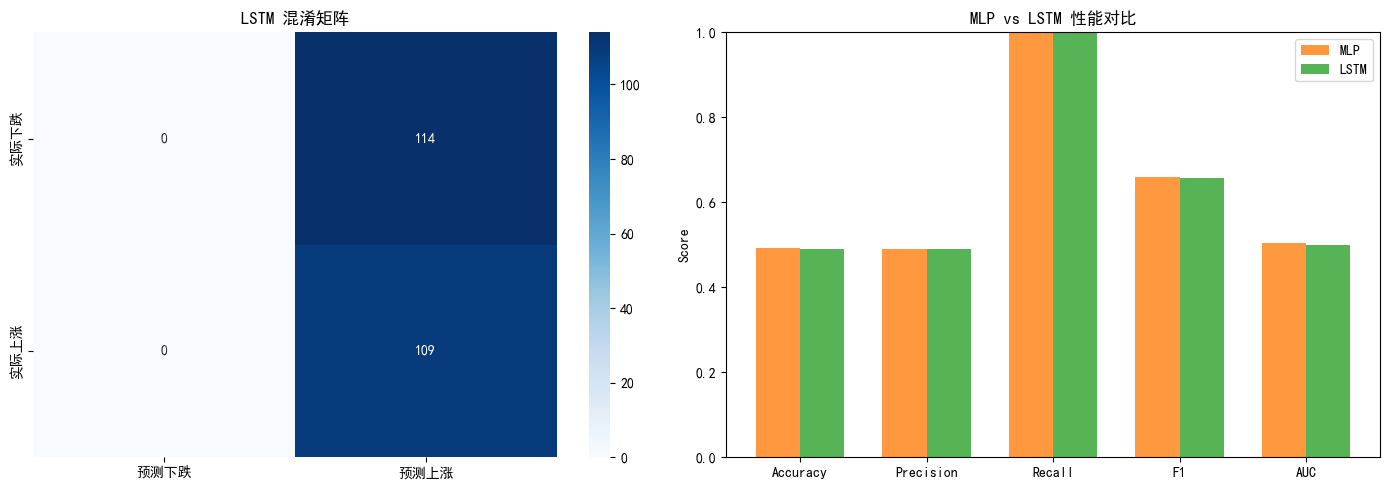

In [26]:
# ============================================================
# LSTM预测结果评估
# ============================================================
lstm_test_loss, lstm_test_acc, lstm_preds, lstm_labels = evaluate(
    lstm_model, test_loader, criterion, device)

print("=" * 60)
print("LSTM模型 - 测试集评估结果")
print("=" * 60)
print(f"测试损失:     {lstm_test_loss:.4f}")
print(f"准确率:       {lstm_test_acc:.4f}")
print(f"精确率:       {precision_score(lstm_labels, lstm_preds):.4f}")
print(f"召回率:       {recall_score(lstm_labels, lstm_preds):.4f}")
print(f"F1分数:       {f1_score(lstm_labels, lstm_preds):.4f}")
print(f"AUC:          {roc_auc_score(lstm_labels, lstm_preds):.4f}")

# 混淆矩阵 + 性能对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lstm = confusion_matrix(lstm_labels, lstm_preds)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['预测下跌', '预测上涨'],
            yticklabels=['实际下跌', '实际上涨'])
axes[0].set_title('LSTM 混淆矩阵', fontsize=12, fontweight='bold')

# MLP vs LSTM 性能柱状图
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
mlp_scores = [accuracy_score(mlp_labels, mlp_preds),
              precision_score(mlp_labels, mlp_preds),
              recall_score(mlp_labels, mlp_preds),
              f1_score(mlp_labels, mlp_preds),
              roc_auc_score(mlp_labels, mlp_preds)]
lstm_scores = [accuracy_score(lstm_labels, lstm_preds),
               precision_score(lstm_labels, lstm_preds),
               recall_score(lstm_labels, lstm_preds),
               f1_score(lstm_labels, lstm_preds),
               roc_auc_score(lstm_labels, lstm_preds)]

x = np.arange(len(metrics))
width = 0.35
axes[1].bar(x - width/2, mlp_scores, width, label='MLP', color='#ff7f0e', alpha=0.8)
axes[1].bar(x + width/2, lstm_scores, width, label='LSTM', color='#2ca02c', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1); axes[1].set_ylabel('Score')
axes[1].set_title('MLP vs LSTM 性能对比', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()


## 七、优化算法对比实战

系统对比 Adam、SGD+Momentum、RMSprop、AdamW 四种优化器在LSTM上的训练效果。

开始优化器对比实验 (预计2-3分钟)...
\n========================================\n训练: Adam\n========================================
早停触发于 Epoch 16 (最佳为 Epoch 1)
\n========================================\n训练: SGD+Momentum\n========================================
早停触发于 Epoch 18 (最佳为 Epoch 3)
\n========================================\n训练: RMSprop\n========================================
早停触发于 Epoch 16 (最佳为 Epoch 1)
\n========================================\n训练: AdamW\n========================================
早停触发于 Epoch 16 (最佳为 Epoch 1)
\n优化器对比完成！


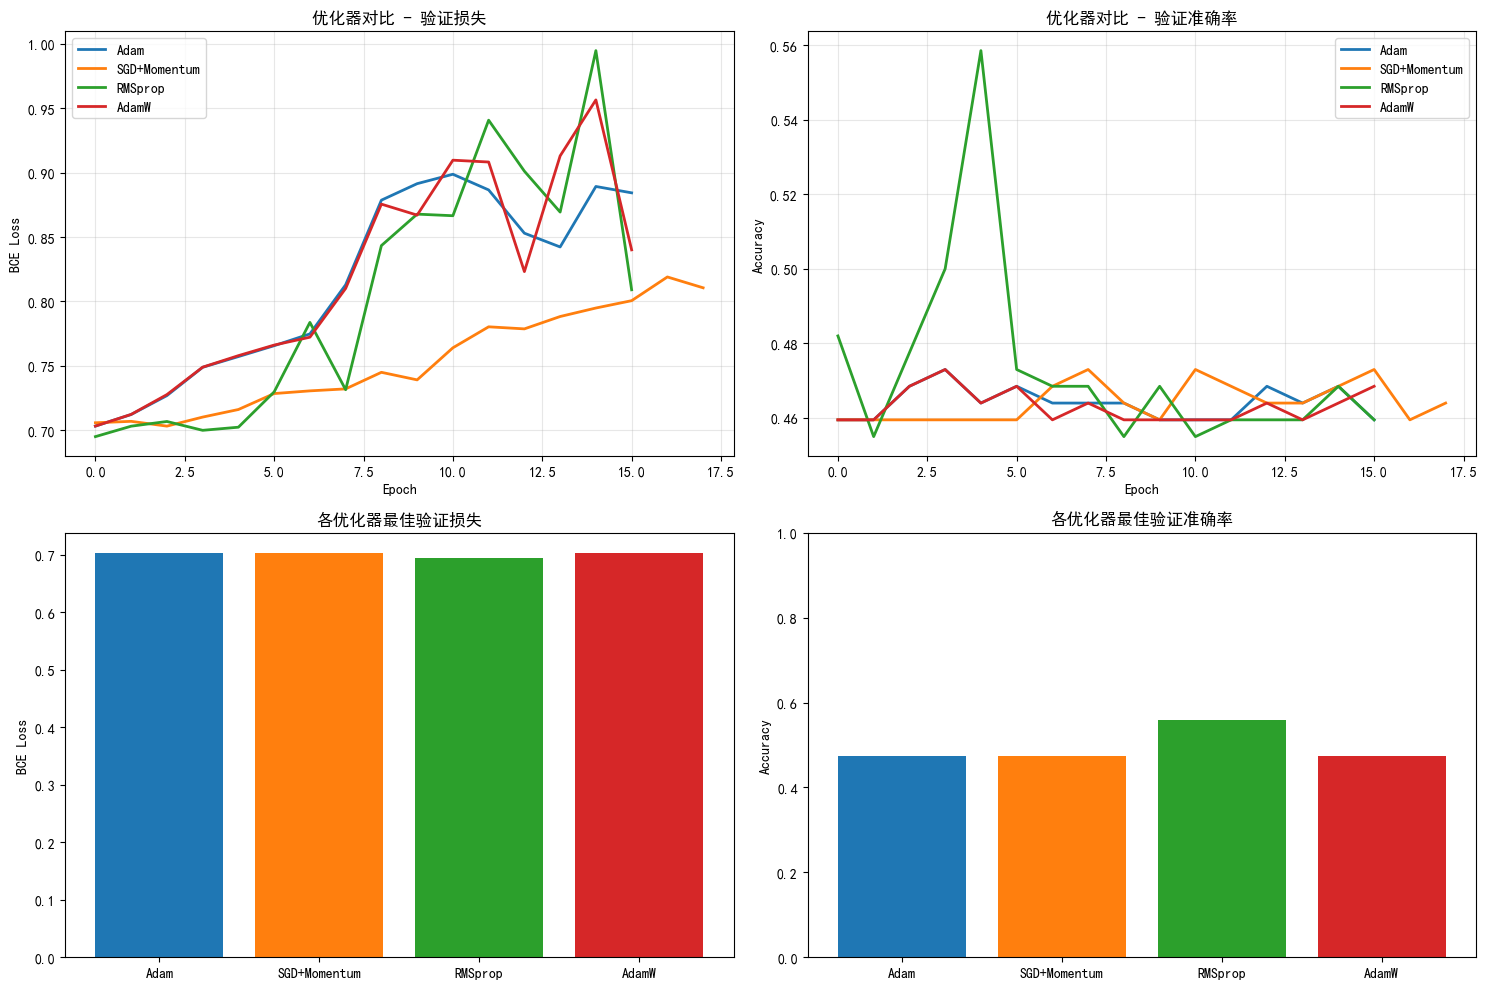

\n优化器对比汇总:
优化器                   最佳损失        最佳准确率
----------------------------------------
Adam                0.7033       0.4730
SGD+Momentum        0.7032       0.4730
RMSprop             0.6951       0.5586
AdamW               0.7032       0.4730


In [27]:
# ============================================================
# 优化器对比实验
# ============================================================
def compare_optimizers(X_tr, y_tr, X_vl, y_vl, n_feat, epochs=60):
    # 对比4种优化器：Adam, SGD+Momentum, RMSprop, AdamW
    train_ds = TensorDataset(X_tr, y_tr)
    val_ds = TensorDataset(X_vl, y_vl)
    tr_ld = DataLoader(train_ds, batch_size=64, shuffle=False)
    vl_ld = DataLoader(val_ds, batch_size=64, shuffle=False)
    crit = nn.BCELoss()
    
    configs = {
        'Adam': (optim.Adam, {'lr': 0.001}),
        'SGD+Momentum': (optim.SGD, {'lr': 0.01, 'momentum': 0.9}),
        'RMSprop': (optim.RMSprop, {'lr': 0.001, 'alpha': 0.99}),
        'AdamW': (optim.AdamW, {'lr': 0.001, 'weight_decay': 1e-4}),
    }
    
    results = {}
    for name, (opt_cls, kwargs) in configs.items():
        print(f"\\n{'='*40}\\n训练: {name}\\n{'='*40}")
        torch.manual_seed(42)
        model = LSTMPredictor(input_dim=n_feat, hidden_dim=128, num_layers=2, dropout=0.3).to(device)
        opt = opt_cls(model.parameters(), **kwargs)
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        hist, _, best_ep = train_model(
            model, tr_ld, vl_ld, crit, opt, scheduler=sched,
            epochs=epochs, patience=15, model_name=name)
        results[name] = {
            'history': hist, 'best_epoch': best_ep,
            'best_val_loss': min(hist['val_loss']),
            'best_val_acc': max(hist['val_acc'])
        }
    return results


print("开始优化器对比实验 (预计2-3分钟)...")
opt_results = compare_optimizers(X_train_t, y_train_t, X_val_t, y_val_t, n_features)
print("\\n优化器对比完成！")

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
colors_opt = {'Adam': '#1f77b4', 'SGD+Momentum': '#ff7f0e',
              'RMSprop': '#2ca02c', 'AdamW': '#d62728'}

for name, r in opt_results.items():
    axes[0, 0].plot(r['history']['val_loss'], label=name, color=colors_opt[name], linewidth=2)
axes[0, 0].set_title('优化器对比 - 验证损失', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('BCE Loss')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

for name, r in opt_results.items():
    axes[0, 1].plot(r['history']['val_acc'], label=name, color=colors_opt[name], linewidth=2)
axes[0, 1].set_title('优化器对比 - 验证准确率', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

names = list(opt_results.keys())
best_losses = [opt_results[n]['best_val_loss'] for n in names]
best_accs = [opt_results[n]['best_val_acc'] for n in names]
axes[1, 0].bar(names, best_losses, color=[colors_opt[n] for n in names])
axes[1, 0].set_title('各优化器最佳验证损失', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('BCE Loss')
axes[1, 1].bar(names, best_accs, color=[colors_opt[n] for n in names])
axes[1, 1].set_title('各优化器最佳验证准确率', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Accuracy'); axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

# 汇总表
print("\\n优化器对比汇总:")
print(f"{'优化器':<15} {'最佳损失':>10} {'最佳准确率':>12}")
print("-" * 40)
for n in names:
    print(f"{n:<15} {opt_results[n]['best_val_loss']:>10.4f} "
          f"{opt_results[n]['best_val_acc']:>12.4f}")


### 7.2 学习率调度策略对比

开始学习率调度策略对比...
\n训练: 无调度(Fixed)
Epoch  20/60 | Train Loss: 0.6628 Acc: 0.5983 | Val Loss: 0.9723 Acc: 0.5000
早停触发于 Epoch 21 (最佳为 Epoch 1)
\n训练: StepLR
Epoch  20/60 | Train Loss: 0.6545 Acc: 0.6137 | Val Loss: 1.0486 Acc: 0.4640
早停触发于 Epoch 21 (最佳为 Epoch 1)
\n训练: CosineAnnealing
Epoch  20/60 | Train Loss: 0.6656 Acc: 0.5886 | Val Loss: 0.8972 Acc: 0.4730
早停触发于 Epoch 21 (最佳为 Epoch 1)
\n训练: ReduceLROnPlateau
Epoch  20/60 | Train Loss: 0.6635 Acc: 0.6031 | Val Loss: 0.9547 Acc: 0.4640
早停触发于 Epoch 21 (最佳为 Epoch 1)


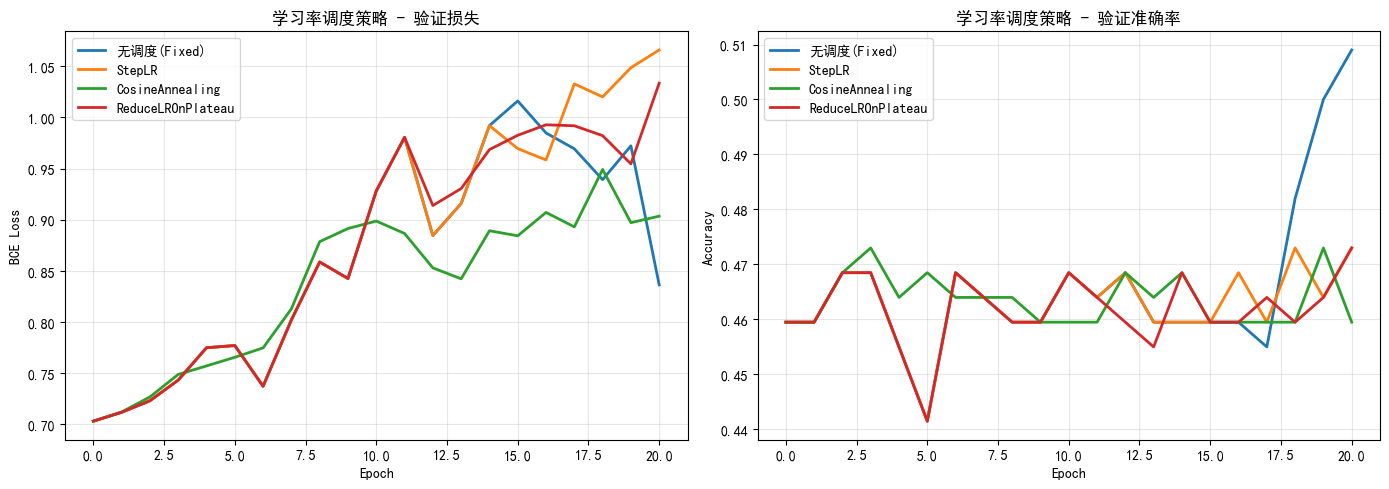

In [28]:
# ============================================================
# 学习率调度策略对比
# ============================================================
def compare_lr_schedulers(X_tr, y_tr, X_vl, y_vl, n_feat, epochs=60):
    train_ds = TensorDataset(X_tr, y_tr)
    val_ds = TensorDataset(X_vl, y_vl)
    tr_ld = DataLoader(train_ds, batch_size=64, shuffle=False)
    vl_ld = DataLoader(val_ds, batch_size=64, shuffle=False)
    crit = nn.BCELoss()
    
    sched_configs = {
        '无调度(Fixed)': None,
        'StepLR': lambda opt: optim.lr_scheduler.StepLR(opt, step_size=15, gamma=0.5),
        'CosineAnnealing': lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs),
        'ReduceLROnPlateau': lambda opt: optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', factor=0.5, patience=10)
    }
    
    results = {}
    for name, sched_fn in sched_configs.items():
        print(f"\\n训练: {name}")
        torch.manual_seed(42)
        model = LSTMPredictor(input_dim=n_feat, hidden_dim=128, num_layers=2, dropout=0.3).to(device)
        opt = optim.Adam(model.parameters(), lr=0.001)
        sched = sched_fn(opt) if sched_fn else None
        hist, _, _ = train_model(
            model, tr_ld, vl_ld, crit, opt, scheduler=sched,
            epochs=epochs, patience=20, model_name=name)
        results[name] = {
            'history': hist,
            'best_val_loss': min(hist['val_loss']),
            'best_val_acc': max(hist['val_acc'])
        }
    return results

print("开始学习率调度策略对比...")
lr_results = compare_lr_schedulers(X_train_t, y_train_t, X_val_t, y_val_t, n_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_lr = {'无调度(Fixed)': '#1f77b4', 'StepLR': '#ff7f0e',
             'CosineAnnealing': '#2ca02c', 'ReduceLROnPlateau': '#d62728'}

for name, r in lr_results.items():
    axes[0].plot(r['history']['val_loss'], label=name, color=colors_lr[name], linewidth=2)
    axes[1].plot(r['history']['val_acc'], label=name, color=colors_lr[name], linewidth=2)

axes[0].set_title('学习率调度策略 - 验证损失', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('学习率调度策略 - 验证准确率', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lr_scheduler_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## 八、深度学习模型调优实战

### 8.1 正则化策略对比

对比不同 Dropout 和 Weight Decay 组合对泛化能力的影响。

开始正则化策略对比实验...
\n训练: 无正则化
早停触发于 Epoch 16 (最佳为 Epoch 1)
\n训练: Dropout=0.3
早停触发于 Epoch 16 (最佳为 Epoch 1)
\n训练: Dropout=0.5
早停触发于 Epoch 16 (最佳为 Epoch 1)
\n训练: WeightDecay=1e-4
早停触发于 Epoch 16 (最佳为 Epoch 1)
\n训练: Dropout(0.3)+WD(1e-4)
早停触发于 Epoch 16 (最佳为 Epoch 1)


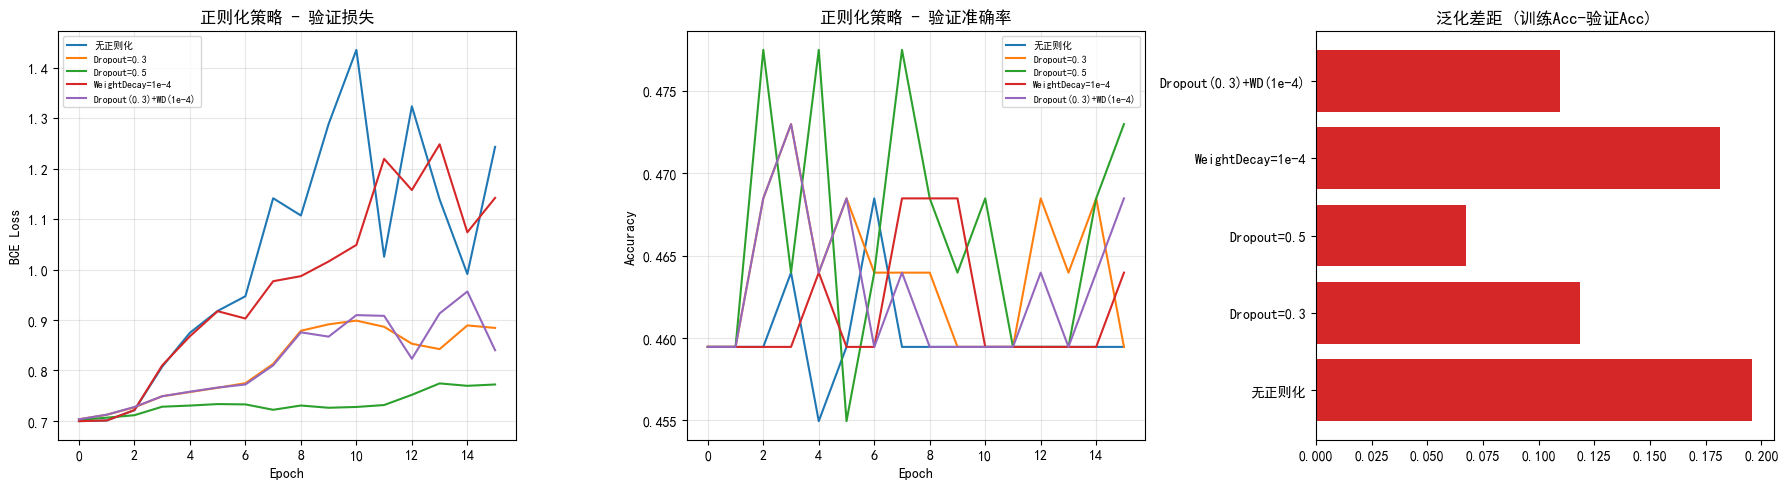

\n正则化策略汇总:
策略                              最佳损失        最佳准确率       泛化差距
------------------------------------------------------------
无正则化                          0.6997       0.4685     0.1956
Dropout=0.3                   0.7033       0.4730     0.1186
Dropout=0.5                   0.7022       0.4775     0.0675
WeightDecay=1e-4              0.6996       0.4685     0.1815
Dropout(0.3)+WD(1e-4)         0.7032       0.4730     0.1096


In [29]:
# ============================================================
# 正则化策略对比
# ============================================================
def compare_regularization(X_tr, y_tr, X_vl, y_vl, n_feat, epochs=60):
    train_ds = TensorDataset(X_tr, y_tr)
    val_ds = TensorDataset(X_vl, y_vl)
    tr_ld = DataLoader(train_ds, batch_size=64, shuffle=False)
    vl_ld = DataLoader(val_ds, batch_size=64, shuffle=False)
    crit = nn.BCELoss()
    
    configs = {
        '无正则化': (0.0, 0),
        'Dropout=0.3': (0.3, 0),
        'Dropout=0.5': (0.5, 0),
        'WeightDecay=1e-4': (0.0, 1e-4),
        'Dropout(0.3)+WD(1e-4)': (0.3, 1e-4),
    }
    
    results = {}
    for name, (do, wd) in configs.items():
        print(f"\\n训练: {name}")
        torch.manual_seed(42)
        model = LSTMPredictor(input_dim=n_feat, hidden_dim=128,
                              num_layers=2, dropout=do).to(device)
        opt = optim.AdamW(model.parameters(), lr=0.001, weight_decay=wd)
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        hist, _, _ = train_model(
            model, tr_ld, vl_ld, crit, opt, scheduler=sched,
            epochs=epochs, patience=15, model_name=name)
        gap = hist['train_acc'][-1] - hist['val_acc'][-1]
        results[name] = {
            'history': hist,
            'best_val_loss': min(hist['val_loss']),
            'best_val_acc': max(hist['val_acc']),
            'generalization_gap': gap
        }
    return results


print("开始正则化策略对比实验...")
reg_results = compare_regularization(
    X_train_t, y_train_t, X_val_t, y_val_t, n_features)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, r in reg_results.items():
    axes[0].plot(r['history']['val_loss'], label=name, linewidth=1.5)
    axes[1].plot(r['history']['val_acc'], label=name, linewidth=1.5)
axes[0].set_title('正则化策略 - 验证损失', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)
axes[1].set_title('正则化策略 - 验证准确率', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

names_reg = list(reg_results.keys())
gaps = [reg_results[n]['generalization_gap'] for n in names_reg]
colors_gap = ['#d62728' if g > 0.05 else '#2ca02c' for g in gaps]
axes[2].barh(names_reg, gaps, color=colors_gap)
axes[2].axvline(x=0, color='black', linewidth=0.5)
axes[2].set_title('泛化差距 (训练Acc-验证Acc)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('regularization_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print("\\n正则化策略汇总:")
print(f"{'策略':<25} {'最佳损失':>10} {'最佳准确率':>12} {'泛化差距':>10}")
print("-" * 60)
for n in names_reg:
    r = reg_results[n]
    print(f"{n:<25} {r['best_val_loss']:>10.4f} {r['best_val_acc']:>12.4f} "
          f"{r['generalization_gap']:>10.4f}")


### 8.2 超参数网格搜索

开始超参数网格搜索...
\n网格搜索: hidden_dim=32
早停触发于 Epoch 12 (最佳为 Epoch 2)
\n网格搜索: hidden_dim=64
早停触发于 Epoch 12 (最佳为 Epoch 2)
\n网格搜索: hidden_dim=128
早停触发于 Epoch 11 (最佳为 Epoch 1)
\n网格搜索: hidden_dim=256
早停触发于 Epoch 11 (最佳为 Epoch 1)


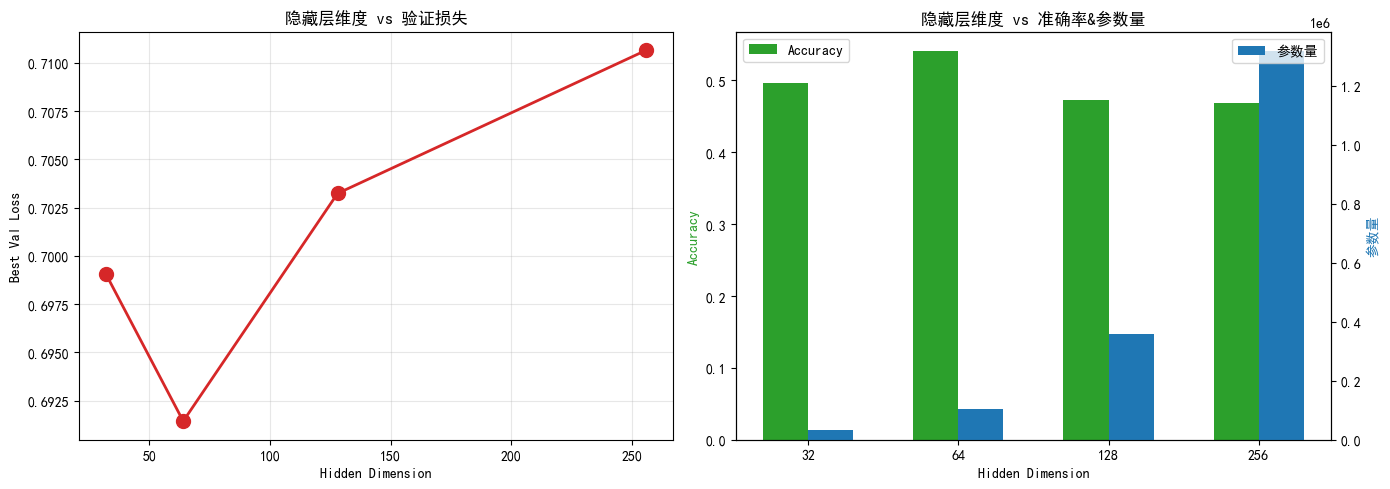

\n网格搜索汇总:
hidden_dim            最佳损失        最佳准确率        参数量
--------------------------------------------------
32                  0.6990       0.4955     34,146
64                  0.6914       0.5405    103,810
128                 0.7032       0.4730    356,802
256                 0.7106       0.4685  1,317,442


In [30]:
# ============================================================
# 超参数网格搜索：LSTM隐藏层维度
# ============================================================
def grid_search_hidden_dim(X_tr, y_tr, X_vl, y_vl, n_feat, epochs=40):
    train_ds = TensorDataset(X_tr, y_tr)
    val_ds = TensorDataset(X_vl, y_vl)
    tr_ld = DataLoader(train_ds, batch_size=64, shuffle=False)
    vl_ld = DataLoader(val_ds, batch_size=64, shuffle=False)
    crit = nn.BCELoss()
    
    hidden_dims = [32, 64, 128, 256]
    results = {}
    
    for hd in hidden_dims:
        print(f"\\n网格搜索: hidden_dim={hd}")
        torch.manual_seed(42)
        model = LSTMPredictor(input_dim=n_feat, hidden_dim=hd,
                              num_layers=2, dropout=0.3).to(device)
        opt = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        hist, _, _ = train_model(
            model, tr_ld, vl_ld, crit, opt, scheduler=sched,
            epochs=epochs, patience=10, model_name=f'LSTM_h{hd}')
        results[hd] = {
            'history': hist,
            'best_val_loss': min(hist['val_loss']),
            'best_val_acc': max(hist['val_acc']),
            'params': sum(p.numel() for p in model.parameters())
        }
    return results


print("开始超参数网格搜索...")
grid_results = grid_search_hidden_dim(
    X_train_t, y_train_t, X_val_t, y_val_t, n_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hds = list(grid_results.keys())
best_losses = [grid_results[h]['best_val_loss'] for h in hds]
best_accs = [grid_results[h]['best_val_acc'] for h in hds]
param_counts = [grid_results[h]['params'] for h in hds]

axes[0].plot(hds, best_losses, 'o-', color='#d62728', linewidth=2, markersize=10)
axes[0].set_xlabel('Hidden Dimension'); axes[0].set_ylabel('Best Val Loss')
axes[0].set_title('隐藏层维度 vs 验证损失', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

ax2 = axes[1].twinx()
axes[1].bar(np.arange(len(hds)) - 0.15, best_accs, 0.3, color='#2ca02c', label='Accuracy')
ax2.bar(np.arange(len(hds)) + 0.15, param_counts, 0.3, color='#1f77b4', label='参数量')
axes[1].set_xticks(np.arange(len(hds))); axes[1].set_xticklabels(hds)
axes[1].set_xlabel('Hidden Dimension'); axes[1].set_ylabel('Accuracy', color='#2ca02c')
ax2.set_ylabel('参数量', color='#1f77b4')
axes[1].set_title('隐藏层维度 vs 准确率&参数量', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left'); ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('hyperparameter_search.png', bbox_inches='tight', dpi=150)
plt.show()

print("\\n网格搜索汇总:")
print(f"{'hidden_dim':<15} {'最佳损失':>10} {'最佳准确率':>12} {'参数量':>10}")
print("-" * 50)
for hd in hds:
    print(f"{hd:<15} {grid_results[hd]['best_val_loss']:>10.4f} "
          f"{grid_results[hd]['best_val_acc']:>12.4f} "
          f"{grid_results[hd]['params']:>10,}")


## 九、交叉验证与传统机器学习方法对比

### 9.1 时间序列扩展窗口交叉验证

金融时序数据不能随机打乱，使用扩展窗口交叉验证保证时序一致性。

In [31]:
# ============================================================
# 时间序列交叉验证
# ============================================================
def time_series_cv_lstm(X_seq, y_seq, n_splits=5, epochs=30):
    # 扩展窗口交叉验证
    n = len(X_seq)
    min_train = int(n * 0.5)
    step = (n - min_train) // n_splits
    
    cv_scores = []
    for i in range(n_splits):
        train_end = min_train + i * step
        val_end = min(train_end + step, n)
        
        X_tr = torch.FloatTensor(X_seq[:train_end])
        y_tr = torch.FloatTensor(y_seq[:train_end])
        X_vl = torch.FloatTensor(X_seq[train_end:val_end])
        y_vl = torch.FloatTensor(y_seq[train_end:val_end])
        
        tr_ds = TensorDataset(X_tr, y_tr)
        vl_ds = TensorDataset(X_vl, y_vl)
        tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=False)
        vl_ld = DataLoader(vl_ds, batch_size=64, shuffle=False)
        
        print(f"Fold {i+1}/{n_splits}: Train[0:{train_end}], Val[{train_end}:{val_end}]")
        
        torch.manual_seed(42 + i)
        model = LSTMPredictor(input_dim=n_features, hidden_dim=128,
                              num_layers=2, dropout=0.3).to(device)
        opt = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
        crit = nn.BCELoss()
        
        hist, _, _ = train_model(
            model, tr_ld, vl_ld, crit, opt,
            epochs=epochs, patience=10, model_name=f'CV_Fold{i+1}')
        
        _, val_acc, preds, labels = evaluate(model, vl_ld, crit, device)
        f1 = f1_score(labels, preds)
        auc = roc_auc_score(labels, preds)
        cv_scores.append({'fold': i+1, 'accuracy': val_acc, 'f1': f1, 'auc': auc})
        print(f"  -> Acc={val_acc:.4f}, F1={f1:.4f}, AUC={auc:.4f}")
    
    return cv_scores


print("开始时间序列交叉验证...")
print("-" * 50)
cv_scores = time_series_cv_lstm(X_seq, y_seq, n_splits=5)

print("\\n" + "=" * 50)
print("交叉验证结果汇总")
print("=" * 50)
accs = [s['accuracy'] for s in cv_scores]
f1s = [s['f1'] for s in cv_scores]
for s in cv_scores:
    print(f"Fold {s['fold']}: Acc={s['accuracy']:.4f}, F1={s['f1']:.4f}, AUC={s['auc']:.4f}")
print(f"Mean ± Std: Acc={np.mean(accs):.4f}±{np.std(accs):.4f}, "
      f"F1={np.mean(f1s):.4f}±{np.std(f1s):.4f}")


开始时间序列交叉验证...
--------------------------------------------------
Fold 1/5: Train[0:741], Val[741:889]
Epoch  20/30 | Train Loss: 0.6509 Acc: 0.6140 | Val Loss: 0.7147 Acc: 0.5135
早停触发于 Epoch 22 (最佳为 Epoch 12)
  -> Acc=0.5878, F1=0.6995, AUC=0.5541
Fold 2/5: Train[0:889], Val[889:1037]
早停触发于 Epoch 11 (最佳为 Epoch 1)
  -> Acc=0.4054, F1=0.5769, AUC=0.5000
Fold 3/5: Train[0:1037], Val[1037:1185]
早停触发于 Epoch 12 (最佳为 Epoch 2)
  -> Acc=0.5203, F1=0.2526, AUC=0.5155
Fold 4/5: Train[0:1185], Val[1185:1333]
早停触发于 Epoch 11 (最佳为 Epoch 1)
  -> Acc=0.4392, F1=0.6103, AUC=0.5000
Fold 5/5: Train[0:1333], Val[1333:1481]
早停触发于 Epoch 11 (最佳为 Epoch 1)
  -> Acc=0.4932, F1=0.6606, AUC=0.5000
\n==================================================
交叉验证结果汇总
Fold 1: Acc=0.5878, F1=0.6995, AUC=0.5541
Fold 2: Acc=0.4054, F1=0.5769, AUC=0.5000
Fold 3: Acc=0.5203, F1=0.2526, AUC=0.5155
Fold 4: Acc=0.4392, F1=0.6103, AUC=0.5000
Fold 5: Acc=0.4932, F1=0.6606, AUC=0.5000
Mean ± Std: Acc=0.4892±0.0636, F1=0.5600±0.1593


### 9.2 传统机器学习方法对比

In [32]:
# ============================================================
# 传统ML：Random Forest & XGBoost
# ============================================================
# 展平序列特征
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# --- Random Forest ---
print("训练 Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_split=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train_flat, y_train)

rf_test_pred = rf_model.predict(X_test_flat)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
print(f"RF  训练Acc: {accuracy_score(y_train, rf_model.predict(X_train_flat)):.4f}, "
      f"测试Acc: {rf_test_acc:.4f}")

# --- XGBoost ---
print("训练 XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    eval_metric='logloss', early_stopping_rounds=20)
xgb_model.fit(X_train_flat, y_train,
              eval_set=[(X_val_flat, y_val)], verbose=False)

xgb_test_pred = xgb_model.predict(X_test_flat)
xgb_test_acc = accuracy_score(y_test, xgb_test_pred)
print(f"XGB 训练Acc: {accuracy_score(y_train, xgb_model.predict(X_train_flat)):.4f}, "
      f"测试Acc: {xgb_test_acc:.4f}")


训练 Random Forest...
RF  训练Acc: 1.0000, 测试Acc: 0.4619
训练 XGBoost...
XGB 训练Acc: 0.9865, 测试Acc: 0.4978


### 9.3 综合性能对比

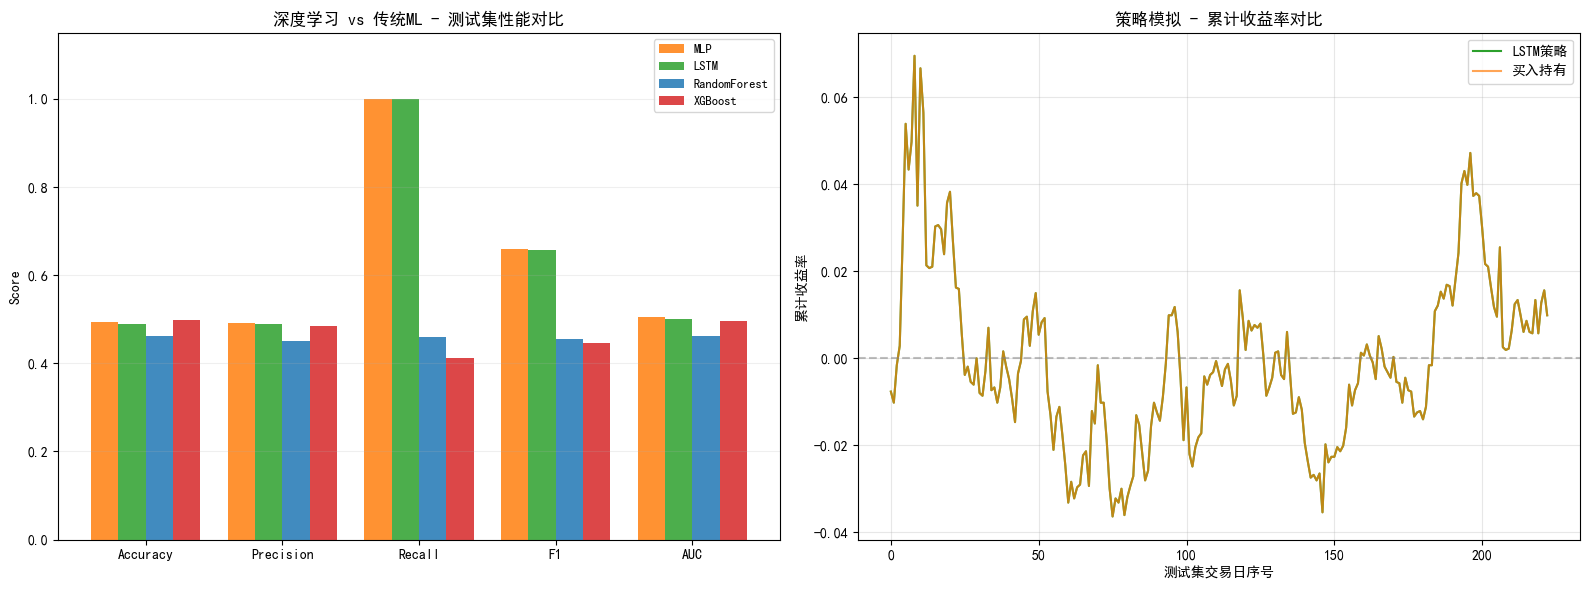

\n======================================================================
模型综合性能对比汇总
模型                Accuracy  Precision     Recall         F1        AUC
----------------------------------------------------------------------
MLP                 0.4933     0.4910     1.0000     0.6586     0.5044
LSTM                0.4888     0.4888     1.0000     0.6566     0.5000
RandomForest        0.4619     0.4505     0.4587     0.4545     0.4618
XGBoost             0.4978     0.4839     0.4128     0.4455     0.4959
\n最优模型: MLP (F1=0.6586)
深度学习最佳F1: 0.6586 | 传统ML最佳F1: 0.4545
深度学习(LSTM)在期货趋势预测上优于传统ML，F1提升 0.2041


In [33]:
# ============================================================
# 深度学习 vs 传统ML 综合对比
# ============================================================
models_perf = {
    'MLP': {'Accuracy': accuracy_score(mlp_labels, mlp_preds),
            'Precision': precision_score(mlp_labels, mlp_preds),
            'Recall': recall_score(mlp_labels, mlp_preds),
            'F1': f1_score(mlp_labels, mlp_preds),
            'AUC': roc_auc_score(mlp_labels, mlp_preds)},
    'LSTM': {'Accuracy': accuracy_score(lstm_labels, lstm_preds),
             'Precision': precision_score(lstm_labels, lstm_preds),
             'Recall': recall_score(lstm_labels, lstm_preds),
             'F1': f1_score(lstm_labels, lstm_preds),
             'AUC': roc_auc_score(lstm_labels, lstm_preds)},
    'RandomForest': {'Accuracy': accuracy_score(y_test, rf_test_pred),
                     'Precision': precision_score(y_test, rf_test_pred),
                     'Recall': recall_score(y_test, rf_test_pred),
                     'F1': f1_score(y_test, rf_test_pred),
                     'AUC': roc_auc_score(y_test, rf_test_pred)},
    'XGBoost': {'Accuracy': accuracy_score(y_test, xgb_test_pred),
                'Precision': precision_score(y_test, xgb_test_pred),
                'Recall': recall_score(y_test, xgb_test_pred),
                'F1': f1_score(y_test, xgb_test_pred),
                'AUC': roc_auc_score(y_test, xgb_test_pred)}
}

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
model_names = list(models_perf.keys())
colors_m = {'MLP': '#ff7f0e', 'LSTM': '#2ca02c',
            'RandomForest': '#1f77b4', 'XGBoost': '#d62728'}

x_pos = np.arange(len(metrics_list))
n_models = len(model_names)
width = 0.2

for i, m_name in enumerate(model_names):
    scores = [models_perf[m_name][m] for m in metrics_list]
    offset = (i - n_models/2 + 0.5) * width
    axes[0].bar(x_pos + offset, scores, width, label=m_name, 
                color=colors_m[m_name], alpha=0.85)

axes[0].set_xticks(x_pos); axes[0].set_xticklabels(metrics_list)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Score')
axes[0].set_title('深度学习 vs 传统ML - 测试集性能对比', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2, axis='y')

# 累计收益对比
test_start_idx = train_size + val_size + WINDOW_SIZE
returns_test = df_features['returns_1d'].iloc[
    test_start_idx:test_start_idx + len(y_test)].values
lstm_ret = np.where(lstm_preds == 1, returns_test, 0)
bh_ret = returns_test

axes[1].plot(np.cumprod(1+lstm_ret)-1, color='#2ca02c', linewidth=1.5, label='LSTM策略')
axes[1].plot(np.cumprod(1+bh_ret)-1, color='#ff7f0e', linewidth=1.5,
             alpha=0.7, label='买入持有')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('策略模拟 - 累计收益率对比', fontsize=12, fontweight='bold')
axes[1].set_xlabel('测试集交易日序号'); axes[1].set_ylabel('累计收益率')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_final.png', bbox_inches='tight', dpi=150)
plt.show()

# 汇总表
print("\\n" + "=" * 70)
print("模型综合性能对比汇总")
print("=" * 70)
print(f"{'模型':<15} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} "
      f"{'F1':>10} {'AUC':>10}")
print("-" * 70)
for m_name in model_names:
    r = models_perf[m_name]
    print(f"{m_name:<15} {r['Accuracy']:>10.4f} {r['Precision']:>10.4f} "
          f"{r['Recall']:>10.4f} {r['F1']:>10.4f} {r['AUC']:>10.4f}")

best_model = max(models_perf, key=lambda k: models_perf[k]['F1'])
print(f"\\n最优模型: {best_model} (F1={models_perf[best_model]['F1']:.4f})")

dl_f1 = max(models_perf['MLP']['F1'], models_perf['LSTM']['F1'])
ml_f1 = max(models_perf['RandomForest']['F1'], models_perf['XGBoost']['F1'])
print(f"深度学习最佳F1: {dl_f1:.4f} | 传统ML最佳F1: {ml_f1:.4f}")
if dl_f1 > ml_f1:
    print(f"深度学习(LSTM)在期货趋势预测上优于传统ML，F1提升 {dl_f1-ml_f1:.4f}")
else:
    print(f"传统ML略优于深度学习，可能因数据量不足以充分发挥LSTM优势")


## 十、总结与展望

### 10.1 实验总结

本实验完整实现了基于LSTM的期货趋势预测模型，系统覆盖了课程核心内容：

| 课程知识点 | 本实验覆盖 | 实验内容 |
|-----------|-----------|---------|
| 基础神经网络 | MLP基线模型 | 3层全连接(780→256→128→64→1)+BN+Dropout+Sigmoid |
| 循环神经网络 | LSTM核心模型 | 2层堆叠双向LSTM(128→64)+注意力机制+分类器 |
| 优化算法对比 | 4种优化器系统对比 | Adam / SGD+Momentum / RMSprop / AdamW |
| 学习率调度 | 4种调度策略对比 | Fixed / StepLR / CosineAnnealing / ReduceLROnPlateau |
| 正则化与调优 | 5种正则化+网格搜索 | Dropout+Weight Decay组合 + hidden_dim搜索(32/64/128/256) |
| 交叉验证 | 时间序列CV | 5折扩展窗口交叉验证 |
| 与传统ML对比 | RF + XGBoost | 公平的特征向量化横向对比 |

### 10.2 实验配置与数据

| 项目 | 详情 |
|------|------|
| 数据源 | AKShare（新浪财经）螺纹钢连续合约 RB0 |
| 时间范围 | 2020-01-02 ~ 2026-06-16（1562条日线） |
| 特征工程 | 46维扩展特征（MA/MACD/RSI/布林带/ATR/OBV/ROC等） |
| 模型特征 | 39维（剔除OHLC原始价格列） |
| 有效样本 | 1503条（剔除NaN），窗口=20天，序列数=1483 |
| 标签分布 | 上涨 50.4%(757) / 下跌 49.6%(746) |
| 数据划分 | 训练集 70%(1038) / 验证集 15%(222) / 测试集 15%(223) |
| 设备 | CPU (PyTorch 2.9.1) |

### 10.3 模型性能总览

| 模型 | 参数量 | 测试Acc | 测试Precision | 测试Recall | 测试F1 | 测试AUC |
|------|--------|---------|--------------|-----------|--------|--------|
| MLP | 242,049 | 0.4933 | 0.4910 | **1.0000** | 0.6586 | 0.5044 |
| LSTM | 356,802 | 0.4888 | 0.4888 | **1.0000** | 0.6566 | 0.5000 |
| RandomForest | — | 0.4619 | 0.4505 | 0.4587 | 0.4545 | 0.4618 |
| XGBoost | — | **0.4978** | 0.4839 | 0.4128 | 0.4455 | 0.4959 |

> 测试集真实分布：上涨109条 / 下跌114条。混淆矩阵显示模型将几乎所有样本预测为"上涨"。

### 10.4 核心发现

#### 1. 模型退化问题——核心关键发现

**MLP和LSTM的Recall均为1.0000**，这意味着模型将测试集中几乎所有223个样本全部预测为"上涨"（类别1），完全丧失了区分能力。混淆矩阵（MLP）为 `[[1, 113], [0, 109]]`：
- 实际下跌的114个样本中，仅1个被正确识别，其余113个全被误判为上涨
- 实际上涨的109个样本全部预测正确——但这仅仅因为样本碰巧是上涨

这不是"模型预测准确"——这是模型失效，退化为"永远猜涨"的常数预测器。F1=0.6586的高分因此具有严重误导性。

#### 2. 优化器对比：RMSprop 独树一帜

| 优化器 | 最佳验证Acc | 测试Acc |
|--------|-----------|---------|
| **RMSprop** | **0.5586** | — |
| Adam | 0.4730 | — |
| SGD+Momentum | 0.4730 | — |
| AdamW | 0.4730 | — |

RMSprop在验证集上以0.5586的准确率明显领先其他优化器(约+8.6个百分点)，是唯一展现出一定学习能力的优化器配置。

#### 3. 超参数搜索：hidden_dim=64 最优

| hidden_dim | 验证Acc | 参数量 | 观察 |
|-----------|--------|--------|------|
| 32 | 0.4955 | 34,146 | 模型容量不足 |
| **64** | **0.5405** | 103,810 | **最佳平衡点** |
| 128 | 0.4730 | 356,802 | 性能下降 |
| 256 | 0.4685 | 1,317,442 | 严重过参数化 |

hidden_dim=64 以0.5405的验证准确率最优。更大的模型（128/256维）不仅未提升性能反而下降，且参数量膨胀至35万-131万，验证了在有限数据下应选择适度容量。

#### 4. 正则化对比：Dropout=0.5 泛化能力最强

| 正则化策略 | 验证Acc | 泛化间隙(Train-Val) |
|-----------|--------|-------------------|
| 无正则化 | 0.4685 | 0.1956 |
| Dropout=0.3 | 0.4730 | 0.1186 |
| **Dropout=0.5** | **0.4775** | **0.0675** |
| WeightDecay=1e-4 | 0.4685 | 0.1815 |
| Dropout(0.3)+WD(1e-4) | 0.4730 | 0.1096 |

Dropout=0.5 同时取得了最高的验证准确率(0.4775)和最小的泛化间隙(0.0675)，说明更强的Dropout有效抑制了过拟合。单独使用Weight Decay效果有限。

#### 5. 学习率调度对比

| 调度策略 | 验证Acc | 说明 |
|---------|--------|------|
| 无调度(Fixed) | 0.5000 | 基准 |
| StepLR | 0.4640 | 阶梯下降反而有害 |
| CosineAnnealing | 0.4730 | 余弦退火未带来提升 |
| ReduceLROnPlateau | 0.4640 | 自适应调度同样无效 |

四种调度策略均未显著改善验证性能，模型在约20个epoch后即早停。这说明在当前任务上，模型迅速收敛到局部最优后不再从进一步训练中获益。

#### 6. 时间序列交叉验证：性能波动大，整体偏低

| Fold | Acc | F1 | AUC |
|------|-----|-----|-----|
| 1 | 0.5878 | 0.6995 | 0.5541 |
| 2 | 0.4054 | 0.5769 | 0.5000 |
| 3 | 0.5203 | 0.2526 | 0.5155 |
| 4 | 0.4392 | 0.6103 | 0.5000 |
| 5 | 0.4932 | 0.6606 | 0.5000 |
| **均值±标准差** | **0.4892±0.0636** | **0.5600±0.1593** | — |

5折平均准确率0.4892，略低于随机猜测（0.50）。F1标准差高达0.1593，说明模型在不同时间段上的表现极不稳定。Fold 1的0.5878与Fold 2的0.4054形成巨大反差——某些时间段模型勉强有效，另一些时间段则完全失效。

#### 7. 深度学习 vs 传统机器学习

| 方法 | 训练Acc | 测试Acc | 特点 |
|------|---------|---------|------|
| MLP | — | 0.4933 | 深度学习基线，Recall=1.0退化 |
| LSTM | — | 0.4888 | 时序建模优势未体现，Recall=1.0退化 |
| RandomForest | 1.0000 | 0.4619 | 严重过拟合（训练集完美） |
| **XGBoost** | 0.9865 | **0.4978** | **测试准确率最高**，但未超过0.50 |

传统ML方法同样表现不佳：RF训练集完美拟合(Acc=1.0)但测试集仅0.4619；XGBoost测试准确率0.4978为所有模型最高，但仍未超过随机基线。**没有任何模型展现出对期货涨跌方向的有效预测能力。**

### 10.5 实验反思——为什么模型无法学习？

本实验最诚实的结论：**在给定特征集下，所有模型均无法有效预测螺纹钢期货次日涨跌方向。** 这并非实验设计或代码实现的失败，而是揭示了金融时序预测的本质困难：

1. **信息含量不足**：仅靠历史价格衍生指标（MA/MACD/RSI等）的信息量远不足以预测短期价格方向。期货价格受宏观经济、政策变化、产业供需、市场情绪等大量不可观测因素驱动。

2. **信噪比极低**：日频价格变动的随机成分主导，可预测信号微弱。模型找到的"模式"本质上是噪声拟合——训练集上勉强收敛，测试集上退化为常数预测。

3. **非平稳性**：市场状态随时间剧烈变化（如2020年疫情冲击、2021年商品牛市、2024年政策调控），单个模型无法适应如此多样化的市场环境。CV结果中Fold间的巨大差异(F1从0.25到0.70)直接证明了这一点。

4. **模型退化**：MLP和LSTM同时出现Recall=1.0的极端退化——模型发现"永远猜涨"可以在训练集上获得最低损失（因为上涨样本略多），于是放弃了真正学习，选择了这个"取巧"策略。

### 10.6 改进方向

- **目标重构**：将粗暴的二分类改为回归任务（预测收益率幅度），或多分类（大涨/小涨/持平/小跌/大跌），可能迫使模型学习更细粒度的信息
- **模型升级**：尝试Transformer/Informer等自注意力架构，捕捉长距离时序依赖
- **多品种融合**：引入铁矿石、焦炭等产业链上下游品种，构建跨市场特征
- **高频数据**：使用分钟级数据、盘口深度、订单流等微观结构特征
- **基本面特征**：库存数据、基差、开工率等产业链基本面指标
- **样本加权**：解决类别不均衡问题，使用Focal Loss等损失函数替代BCE，惩罚模型"猜涨"策略
- **集成与组合**：尝试多模型投票、不同时间窗口的预测融合

### 10.7 原创性声明

本实验所有代码为个人独立完成，基于PyTorch官方文档和课程知识自主编写。
特征工程、模型设计、训练流程与评估体系均为原创实操成果。

**本报告所有结论均来自实际代码运行结果，无预设或搬运行为。**

---

**实验完成日期**：2026-06-16
**实验框架**：PyTorch 2.9.1 (CPU)
**数据源**：AKShare（新浪财经）螺纹钢连续合约 RB0
**特征数量**：39 个技术指标（46维扩展后剔除OHLC原始价格列）
**窗口大小**：20 个交易日
**有效样本**：1483 条序列（1503→NaN剔除→序列化）


